In [ ]:
import pandas as pd
df_disparos_onehot = pd.read_csv("drive/MyDrive/tfg/disparos_final.csv")
df_freeze=pd.read_csv("drive/MyDrive/tfg/freeze_frames.csv")

In [ ]:
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pickle
df = pd.read_csv('/content/drive/MyDrive/tfg/datos.csv')

# -------------------------------------------------------------------
# 1) Agregar features agregadas por tiro
# -------------------------------------------------------------------


# -------------------------------------------------------------------
# 2) Preparar DataFrame principal y unir freeze frame
# -------------------------------------------------------------------

# Rellenar nulos
fill_median_cols = ["n_teammates","n_opponents","avg_teammate_x","avg_teammate_y",
                    "avg_opponent_x","avg_opponent_y","goalkeeper_x","goalkeeper_y"]
for c in fill_median_cols:
    df[c] = df[c].fillna(0)
bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time","goalkeeper_present"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)
# -------------------------------------------------------------------
# 3) Ingeniería de variables geométricas
# -------------------------------------------------------------------
GOAL_X = 120.0
POST_LOW_Y = 36.0
POST_HIGH_Y = 44.0
GOAL_CENTER_Y = 40.0

def shot_distance(x, y):
    return np.sqrt((GOAL_X - x)**2 + (GOAL_CENTER_Y - y)**2)

def shot_angle(x, y):
    dx = GOAL_X - x
    if dx <= 0:
        return 0.0
    dy1 = POST_HIGH_Y - y
    dy2 = POST_LOW_Y - y
    v1 = np.array([dx, dy1], dtype=float)
    v2 = np.array([dx, dy2], dtype=float)
    dot = (v1 * v2).sum()
    cross = abs(v1[0]*v2[1] - v1[1]*v2[0])
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return np.arctan2(cross, dot)

for col in ["location_x", "location_y", "under_pressure", "open_goal",
            "aerial_won", "follows_dribble", "first_time"]:
    if col not in df.columns:
        df[col] = np.nan

df["shot_distance"] = df[["location_x","location_y"]].apply(
    lambda r: shot_distance(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)
df["shot_angle"] = df[["location_x","location_y"]].apply(
    lambda r: shot_angle(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)

df["angle_sin"] = np.sin(df["shot_angle"])
df["angle_cos"] = np.cos(df["shot_angle"])
df["distance_sq"] = df["shot_distance"]**2
df["distance_angle_interaction"] = df["shot_distance"] * df["shot_angle"]

bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)

geom_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin",
             "angle_cos","distance_sq","distance_angle_interaction"]
for c in geom_cols:
    df[c] = df[c].fillna(df[c].median())

# -------------------------------------------------------------------
# 4) Selección de features
# -------------------------------------------------------------------
prefixes = ["shot_technique_", "shot_body_part_", "shot_type_"]
dummy_cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]

num_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin","angle_cos",
            "distance_sq","distance_angle_interaction","n_teammates","n_opponents",
            "avg_teammate_x","avg_teammate_y","avg_opponent_x","avg_opponent_y",
            "goalkeeper_present","goalkeeper_x","goalkeeper_y"] + bool_cols

feature_cols = num_cols + dummy_cols

df = df.dropna(subset=["is_goal"])
y = df["is_goal"].astype(float).values
X = df[feature_cols].values

# -------------------------------------------------------------------
# 5) Split + Escalado
# -------------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# -------------------------------------------------------------------
# 6) Tensores y DataLoaders
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

# -------------------------------------------------------------------
# 7) Modelo MLP
# -------------------------------------------------------------------
class XGNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.net(x)

model = XGNet(X_train_t.shape[1]).to(device)

# -------------------------------------------------------------------
# 8) Pérdida MSE + Optimizador + Scheduler
# -------------------------------------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# -------------------------------------------------------------------
# 9) Entrenamiento con early stopping
# -------------------------------------------------------------------
epochs = 50
patience = 10
best_val_mse = float("inf")
best_state = None
counter = 0

for epoch in range(1, epochs+1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = torch.sigmoid(model(xb))
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    all_preds = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = torch.sigmoid(model(xb))
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
            all_preds.append(preds.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    y_val_pred = np.vstack(all_preds).ravel()
    val_mse = mean_squared_error(y_val, y_val_pred)

    scheduler.step(val_mse)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state = {
            "model_state": model.state_dict(),
            "scaler": scaler,
            "feature_cols": feature_cols
        }
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping en epoch {epoch}")
            break

    print(f"Epoch {epoch:03d} | train_loss {train_loss:.4f} | val_mse {val_mse:.6f}")

# -------------------------------------------------------------------
# 10) Guardado seguro
# -------------------------------------------------------------------
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)
torch.save(model.state_dict(),"xg_model_weights.pt")
print("✅ Modelo y scaler guardados")

# -------------------------------------------------------------------
# 11) Función de predicción segura
# -------------------------------------------------------------------
def predict_xg(df_new: pd.DataFrame, feature_cols=feature_cols, weights_path="xg_model_weights.pt", scaler_path="scaler.pkl") -> np.ndarray:
    with open(scaler_path,"rb") as f:
        scaler = pickle.load(f)

    X_new = df_new[feature_cols].values
    X_new_scaled = scaler.transform(X_new)

    model = XGNet(len(feature_cols))
    model.load_state_dict(torch.load(weights_path))
    model.eval()

    with torch.no_grad():
        logits = model(torch.tensor(X_new_scaled,dtype=torch.float32))
        probs = torch.sigmoid(logits).numpy().ravel()
    return probs

Epoch 001 | train_loss 0.0923 | val_mse 0.078226
Epoch 002 | train_loss 0.0781 | val_mse 0.077541
Epoch 003 | train_loss 0.0778 | val_mse 0.077495
Epoch 004 | train_loss 0.0775 | val_mse 0.077316
Epoch 005 | train_loss 0.0775 | val_mse 0.077368
Epoch 006 | train_loss 0.0772 | val_mse 0.077296
Epoch 007 | train_loss 0.0772 | val_mse 0.077445
Epoch 008 | train_loss 0.0771 | val_mse 0.077148
Epoch 009 | train_loss 0.0770 | val_mse 0.077259
Epoch 010 | train_loss 0.0769 | val_mse 0.077149
Epoch 011 | train_loss 0.0769 | val_mse 0.076959
Epoch 012 | train_loss 0.0768 | val_mse 0.077025
Epoch 013 | train_loss 0.0769 | val_mse 0.076959
Epoch 014 | train_loss 0.0769 | val_mse 0.077161
Epoch 015 | train_loss 0.0767 | val_mse 0.077077
Epoch 016 | train_loss 0.0766 | val_mse 0.077027
Epoch 017 | train_loss 0.0766 | val_mse 0.076974
Epoch 018 | train_loss 0.0765 | val_mse 0.077075
Epoch 019 | train_loss 0.0765 | val_mse 0.076959
Epoch 020 | train_loss 0.0764 | val_mse 0.076887
Epoch 021 | train_lo

In [ ]:
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pickle


# -------------------------------------------------------------------
# 1) Agregar features agregadas por tiro
# -------------------------------------------------------------------


# -------------------------------------------------------------------
# 2) Preparar DataFrame principal y unir freeze frame
# -------------------------------------------------------------------

# Rellenar nulos
fill_median_cols = ["n_teammates","n_opponents","avg_teammate_x","avg_teammate_y",
                    "avg_opponent_x","avg_opponent_y","goalkeeper_x","goalkeeper_y"]
for c in fill_median_cols:
    df[c] = df[c].fillna(0)
bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time","goalkeeper_present"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)
# -------------------------------------------------------------------
# 3) Ingeniería de variables geométricas
# -------------------------------------------------------------------
GOAL_X = 120.0
POST_LOW_Y = 36.0
POST_HIGH_Y = 44.0
GOAL_CENTER_Y = 40.0

def shot_distance(x, y):
    return np.sqrt((GOAL_X - x)**2 + (GOAL_CENTER_Y - y)**2)

def shot_angle(x, y):
    dx = GOAL_X - x
    if dx <= 0:
        return 0.0
    dy1 = POST_HIGH_Y - y
    dy2 = POST_LOW_Y - y
    v1 = np.array([dx, dy1], dtype=float)
    v2 = np.array([dx, dy2], dtype=float)
    dot = (v1 * v2).sum()
    cross = abs(v1[0]*v2[1] - v1[1]*v2[0])
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return np.arctan2(cross, dot)

for col in ["location_x", "location_y", "under_pressure", "open_goal",
            "aerial_won", "follows_dribble", "first_time"]:
    if col not in df.columns:
        df[col] = np.nan

df["shot_distance"] = df[["location_x","location_y"]].apply(
    lambda r: shot_distance(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)
df["shot_angle"] = df[["location_x","location_y"]].apply(
    lambda r: shot_angle(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)

df["angle_sin"] = np.sin(df["shot_angle"])
df["angle_cos"] = np.cos(df["shot_angle"])
df["distance_sq"] = df["shot_distance"]**2
df["distance_angle_interaction"] = df["shot_distance"] * df["shot_angle"]

bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)

geom_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin",
             "angle_cos","distance_sq","distance_angle_interaction"]
for c in geom_cols:
    df[c] = df[c].fillna(df[c].median())

# -------------------------------------------------------------------
# 4) Selección de features
# -------------------------------------------------------------------
prefixes = ["shot_technique_", "shot_body_part_", "shot_type_"]
dummy_cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]

num_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin","angle_cos",
            "distance_sq","distance_angle_interaction","n_teammates","n_opponents",
            "avg_teammate_x","avg_teammate_y","avg_opponent_x","avg_opponent_y",
            "goalkeeper_present","goalkeeper_x","goalkeeper_y"] + bool_cols

feature_cols = num_cols + dummy_cols

df = df.dropna(subset=["is_goal"])
y = df["is_goal"].astype(float).values
X = df[feature_cols].values

# -------------------------------------------------------------------
# 5) Split + Escalado
# -------------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# -------------------------------------------------------------------
# 6) Tensores y DataLoaders
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

# -------------------------------------------------------------------
# 7) Modelo MLP
# -------------------------------------------------------------------
class XGNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128,1)
        )
    def forward(self, x):
        return self.net(x)

model = XGNet(X_train_t.shape[1]).to(device)

# -------------------------------------------------------------------
# 8) Pérdida MSE + Optimizador + Scheduler
# -------------------------------------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# -------------------------------------------------------------------
# 9) Entrenamiento con early stopping
# -------------------------------------------------------------------
epochs = 50
patience = 10
best_val_mse = float("inf")
best_state = None
counter = 0

for epoch in range(1, epochs+1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = torch.sigmoid(model(xb))
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    all_preds = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = torch.sigmoid(model(xb))
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
            all_preds.append(preds.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    y_val_pred = np.vstack(all_preds).ravel()
    val_mse = mean_squared_error(y_val, y_val_pred)

    scheduler.step(val_mse)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state = {
            "model_state": model.state_dict(),
            "scaler": scaler,
            "feature_cols": feature_cols
        }
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping en epoch {epoch}")
            break

    print(f"Epoch {epoch:03d} | train_loss {train_loss:.4f} | val_mse {val_mse:.6f}")

# -------------------------------------------------------------------
# 10) Guardado seguro
# -------------------------------------------------------------------
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)
torch.save(model.state_dict(),"xg_model_weights.pt")
print("✅ Modelo y scaler guardados")

# -------------------------------------------------------------------
# 11) Función de predicción segura
# -------------------------------------------------------------------
def predict_xg(df_new: pd.DataFrame, feature_cols=feature_cols, weights_path="xg_model_weights.pt", scaler_path="scaler.pkl") -> np.ndarray:
    with open(scaler_path,"rb") as f:
        scaler = pickle.load(f)

    X_new = df_new[feature_cols].values
    X_new_scaled = scaler.transform(X_new)

    model = XGNet(len(feature_cols))
    model.load_state_dict(torch.load(weights_path))
    model.eval()

    with torch.no_grad():
        logits = model(torch.tensor(X_new_scaled,dtype=torch.float32))
        probs = torch.sigmoid(logits).numpy().ravel()
    return probs

Epoch 001 | train_loss 0.0874 | val_mse 0.078042
Epoch 002 | train_loss 0.0782 | val_mse 0.077817
Epoch 003 | train_loss 0.0778 | val_mse 0.077287
Epoch 004 | train_loss 0.0778 | val_mse 0.077413
Epoch 005 | train_loss 0.0775 | val_mse 0.077273
Epoch 006 | train_loss 0.0774 | val_mse 0.077300
Epoch 007 | train_loss 0.0774 | val_mse 0.077282
Epoch 008 | train_loss 0.0774 | val_mse 0.077203
Epoch 009 | train_loss 0.0772 | val_mse 0.077163
Epoch 010 | train_loss 0.0771 | val_mse 0.077370
Epoch 011 | train_loss 0.0774 | val_mse 0.077430
Epoch 012 | train_loss 0.0771 | val_mse 0.077008
Epoch 013 | train_loss 0.0772 | val_mse 0.077190
Epoch 014 | train_loss 0.0771 | val_mse 0.077082
Epoch 015 | train_loss 0.0770 | val_mse 0.077430
Epoch 016 | train_loss 0.0770 | val_mse 0.077021
Epoch 017 | train_loss 0.0768 | val_mse 0.077015
Epoch 018 | train_loss 0.0767 | val_mse 0.076765
Epoch 019 | train_loss 0.0767 | val_mse 0.076985
Epoch 020 | train_loss 0.0767 | val_mse 0.076826
Epoch 021 | train_lo

In [ ]:
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pickle

# -------------------------------------------------------------------
# 1) Copiar DataFrame final
# -------------------------------------------------------------------
df = df_disparos_onehot.copy()  # tu df final con get_dummies
target_col = "is_goal"

# -------------------------------------------------------------------
# 2) Ingeniería de variables geométricas
# -------------------------------------------------------------------
GOAL_X = 120.0
POST_LOW_Y = 36.0
POST_HIGH_Y = 44.0
GOAL_CENTER_Y = 40.0

def shot_distance(x, y):
    return np.sqrt((GOAL_X - x)**2 + (GOAL_CENTER_Y - y)**2)

def shot_angle(x, y):
    dx = GOAL_X - x
    if dx <= 0:
        return 0.0
    dy1 = POST_HIGH_Y - y
    dy2 = POST_LOW_Y - y
    v1 = np.array([dx, dy1], dtype=float)
    v2 = np.array([dx, dy2], dtype=float)
    dot = (v1 * v2).sum()
    cross = abs(v1[0]*v2[1] - v1[1]*v2[0])
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return np.arctan2(cross, dot)

for col in ["location_x", "location_y", "under_pressure", "open_goal",
            "aerial_won", "follows_dribble", "first_time"]:
    if col not in df.columns:
        df[col] = np.nan

df["shot_distance"] = df[["location_x","location_y"]].apply(
    lambda r: shot_distance(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)
df["shot_angle"] = df[["location_x","location_y"]].apply(
    lambda r: shot_angle(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)

df["angle_sin"] = np.sin(df["shot_angle"])
df["angle_cos"] = np.cos(df["shot_angle"])
df["distance_sq"] = df["shot_distance"]**2
df["distance_angle_interaction"] = df["shot_distance"] * df["shot_angle"]

# Boolean -> 0/1
bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)

# Relleno nulos geométricos
geom_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin","angle_cos","distance_sq","distance_angle_interaction"]
for c in geom_cols:
    df[c] = df[c].fillna(df[c].median())

# -------------------------------------------------------------------
# 3) Selección de features
# -------------------------------------------------------------------
prefixes = ["shot_technique_", "shot_body_part_", "shot_type_"]
dummy_cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]

num_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin","angle_cos",
            "distance_sq","distance_angle_interaction"] + bool_cols

feature_cols = num_cols + dummy_cols

df = df.dropna(subset=[target_col])
y = df[target_col].astype(float).values
X = df[feature_cols].values

# -------------------------------------------------------------------
# 4) Split + Escalado
# -------------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# -------------------------------------------------------------------
# 5) Tensores y DataLoaders
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

# -------------------------------------------------------------------
# 6) Modelo MLP optimizado
# -------------------------------------------------------------------
class XGNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.net(x)

model = XGNet(X_train_t.shape[1]).to(device)

# -------------------------------------------------------------------
# 7) Pérdida MSE + Optimizador + Scheduler
# -------------------------------------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# -------------------------------------------------------------------
# 8) Entrenamiento con early stopping
# -------------------------------------------------------------------
epochs = 100
patience = 10
best_val_mse = float("inf")
best_state = None
counter = 0

for epoch in range(1, epochs+1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = torch.sigmoid(model(xb))
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # Validación
    model.eval()
    val_loss = 0.0
    all_preds = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = torch.sigmoid(model(xb))
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
            all_preds.append(preds.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    y_val_pred = np.vstack(all_preds).ravel()
    val_mse = mean_squared_error(y_val, y_val_pred)

    scheduler.step(val_mse)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state = {
            "model_state": model.state_dict(),
            "scaler": scaler,
            "feature_cols": feature_cols
        }
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping en epoch {epoch}")
            break

    print(f"Epoch {epoch:03d} | train_loss {train_loss:.4f} | val_mse {val_mse:.6f}")

# -------------------------------------------------------------------
# 9) Guardado seguro
# -------------------------------------------------------------------
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)
torch.save(model.state_dict(),"xg_model_weights.pt")
print("✅ Modelo y scaler guardados")

# -------------------------------------------------------------------
# 10) Función de predicción segura
# -------------------------------------------------------------------
def predict_xg(df_new: pd.DataFrame, feature_cols=feature_cols, weights_path="xg_model_weights.pt", scaler_path="scaler.pkl") -> np.ndarray:
    with open(scaler_path,"rb") as f:
        scaler = pickle.load(f)

    X_new = df_new[feature_cols].values
    X_new_scaled = scaler.transform(X_new)

    model = XGNet(len(feature_cols))
    model.load_state_dict(torch.load(weights_path))
    model.eval()

    with torch.no_grad():
        logits = model(torch.tensor(X_new_scaled,dtype=torch.float32))
        probs = torch.sigmoid(logits).numpy().ravel()
    return probs

Epoch 001 | train_loss 0.0968 | val_mse 0.080084
Epoch 002 | train_loss 0.0804 | val_mse 0.079767
Epoch 003 | train_loss 0.0801 | val_mse 0.079703
Epoch 004 | train_loss 0.0799 | val_mse 0.080000
Epoch 005 | train_loss 0.0798 | val_mse 0.079722


KeyboardInterrupt: 

In [ ]:

def goalkeeper_info(group):
    # Filtrar solo rivales
    opponents = group[group["teammate"]==False]
    # Ver si hay portero (position == 1)
    gk = opponents[opponents["position"]==1]
    if not gk.empty:
        return pd.Series({
            "goalkeeper_present": 1,
            "goalkeeper_x": gk.iloc[0]["location_x"],
            "goalkeeper_y": gk.iloc[0]["location_y"]
        })
    else:
        return pd.Series({
            "goalkeeper_present": 0,
            "goalkeeper_x": 0,
            "goalkeeper_y":0
        })
# Crear un diccionario de posición x del tirador por event_id
shot_x_dict = df_disparos_onehot.set_index("event_id")["location_x"].to_dict()
shot_y_dict = df_disparos_onehot.set_index("event_id")["location_y"].to_dict()
# Función para filtrar jugadores por delante del tirador
def filter_ahead(group):
    shot_x = shot_x_dict.get(group.name, None)
    shot_y = shot_y_dict.get(group.name, None)
    if shot_x is None:
        return group
    return group[
    (group["location_x"] >= shot_x - 2) &
    ((group["location_y"] >= shot_y - 2) & (group["location_y"] <= 44))|
    ((group["location_y"] <= shot_y + 2) & (group["location_y"] >= 36))
]  # solo jugadores delante o al mismo nivel

df_freeze_filtered = df_freeze.groupby("event_id").apply(filter_ahead).reset_index(drop=True)

# Rehacer agregaciones con df_freeze_filtered
df_freeze_agg = df_freeze_filtered.groupby("event_id").agg(
    n_teammates = ("teammate", lambda x: sum([1 for v in x if v])),
    n_opponents = ("teammate", lambda x: sum([1 for v in x if not v])),
    avg_teammate_x = ("location_x", lambda x: x[df_freeze_filtered.loc[x.index,"teammate"]==True].mean()),
    avg_teammate_y = ("location_y", lambda x: x[df_freeze_filtered.loc[x.index,"teammate"]==True].mean()),
    avg_opponent_x = ("location_x", lambda x: x[df_freeze_filtered.loc[x.index,"teammate"]==False].mean()),
    avg_opponent_y = ("location_y", lambda x: x[df_freeze_filtered.loc[x.index,"teammate"]==False].mean())
).reset_index()

# Agregar info del portero
gk_df = df_freeze_filtered.groupby("event_id").apply(goalkeeper_info).reset_index()
df_freeze_agg = df_freeze_agg.merge(gk_df, on="event_id", how="left")

/tmp/ipython-input-38140568.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_freeze_filtered = df_freeze.groupby("event_id").apply(filter_ahead).reset_index(drop=True)
/tmp/ipython-input-38140568.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gk_df = df_freeze_filtered.groupby("event_id").apply(goalkeeper_info).reset_index()


In [ ]:
df = df_disparos_onehot.copy()
df = df.merge(df_freeze_agg, on="event_id", how="left")
df.to_csv('/content/drive/MyDrive/tfg/datos.csv', index=False)

In [ ]:
import pandas as pd

# Supongamos que tu DataFrame se llama df
df

,event_id,match_id,player,team,minute,location_x,location_y,under_pressure,open_goal,aerial_won,...,play_pattern_Regular Play,n_teammates,n_opponents,avg_teammate_x,avg_teammate_y,avg_opponent_x,avg_opponent_y,goalkeeper_present,goalkeeper_x,goalkeeper_y
0,becd7956-ce44-479e-8fc9-16a2d1f1f349,15946,Lionel Andrés Messi Cuccittini,Barcelona,2,111.5,52.9,False,False,False,...,False,2.0,6.0,99.200000,49.100000,104.250000,47.300000,1.0,116.5,45.6
1,9107d374-2942-4876-a14f-1b9f86901c15,15946,Jordi Alba Ramos,Barcelona,5,113.9,26.4,False,False,False,...,True,0.0,1.0,NaN,NaN,118.800000,36.700000,1.0,118.8,36.7
2,ddd194ca-08fb-43d0-87c2-33647f975f9f,15946,Lionel Andrés Messi Cuccittini,Barcelona,15,93.7,34.7,False,False,False,...,False,1.0,6.0,100.600000,35.700000,100.183333,39.100000,1.0,117.6,38.9
3,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,15946,Rubén Sobrino Pozuelo,Deportivo Alavés,16,109.2,39.1,True,False,True,...,True,0.0,2.0,NaN,NaN,113.450000,39.500000,1.0,117.6,39.0
4,3ed2b107-be17-42d5-9d1b-25006a0e55cb,15946,Luis Alberto Suárez Díaz,Barcelona,18,107.8,24.7,False,False,False,...,False,3.0,6.0,111.800000,39.266667,112.250000,36.966667,1.0,117.6,37.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87106,cccb561c-1197-43c7-ac49-62a08010cf06,9948,Juan Miguel Jiménez López,Real Sociedad,79,101.3,38.6,False,False,False,...,False,3.0,5.0,109.066667,40.900000,109.440000,38.660000,1.0,118.0,39.8
87107,b5ed83ab-a935-42f3-b06f-ae8da3176a71,9948,Asier Illarramendi Andonegi,Real Sociedad,80,92.6,52.3,False,False,False,...,False,4.0,5.0,100.900000,42.900000,104.020000,44.560000,1.0,116.8,41.6
87108,c81a671d-305c-4004-91ba-cdcacaead0b8,9948,Juan Miguel Jiménez López,Real Sociedad,82,103.5,46.2,False,False,False,...,True,0.0,3.0,NaN,NaN,106.233333,43.900000,1.0,116.7,41.5
87109,facd2378-9eef-4a4f-98eb-e774fdcf8bd5,9948,Francisco Alcácer García,Barcelona,84,104.1,51.2,False,False,False,...,True,1.0,5.0,96.900000,40.700000,102.780000,45.180000,1.0,113.8,42.8


In [ ]:

import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, log_loss, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pickle
df = pd.read_csv('/content/drive/MyDrive/tfg/datos.csv')
# -------------------------------------------------------------------
# 0) Preparación inicial
# -------------------------------------------------------------------
# df: tu DataFrame principal con features y target 'is_goal'

# -------------------------------------------------------------------
# 1) Rellenar nulos y tipos
# -------------------------------------------------------------------
fill_median_cols = ["n_teammates","n_opponents","avg_teammate_x","avg_teammate_y",
                    "avg_opponent_x","avg_opponent_y","goalkeeper_x","goalkeeper_y"]
for c in fill_median_cols:
    df[c] = df[c].fillna(0)

bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble",
             "first_time","goalkeeper_present"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)

# -------------------------------------------------------------------
# 2) Ingeniería de variables geométricas
# -------------------------------------------------------------------
GOAL_X = 120.0
POST_LOW_Y = 36.0
POST_HIGH_Y = 44.0
GOAL_CENTER_Y = 40.0

def shot_distance(x, y):
    return np.sqrt((GOAL_X - x)**2 + (GOAL_CENTER_Y - y)**2)

def shot_angle(x, y):
    dx = GOAL_X - x
    if dx <= 0:
        return 0.0
    dy1 = POST_HIGH_Y - y
    dy2 = POST_LOW_Y - y
    v1 = np.array([dx, dy1], dtype=float)
    v2 = np.array([dx, dy2], dtype=float)
    dot = (v1 * v2).sum()
    cross = abs(v1[0]*v2[1] - v1[1]*v2[0])
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return np.arctan2(cross, dot)

for col in ["location_x", "location_y"]:
    if col not in df.columns:
        df[col] = np.nan

df["shot_distance"] = df[["location_x","location_y"]].apply(
    lambda r: shot_distance(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan, axis=1)
df["shot_angle"] = df[["location_x","location_y"]].apply(
    lambda r: shot_angle(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan, axis=1)

df["angle_sin"] = np.sin(df["shot_angle"])
df["angle_cos"] = np.cos(df["shot_angle"])
df["distance_sq"] = df["shot_distance"]**2
df["distance_angle_interaction"] = df["shot_distance"] * df["shot_angle"]

geom_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin",
             "angle_cos","distance_sq","distance_angle_interaction"]
for c in geom_cols:
    df[c] = df[c].fillna(df[c].median())

# -------------------------------------------------------------------
# 3) Selección de features
# -------------------------------------------------------------------
prefixes = ["shot_technique_", "shot_body_part_", "shot_type_"]
dummy_cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]

num_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin","angle_cos",
            "distance_sq","distance_angle_interaction","n_teammates","n_opponents",
            "avg_teammate_x","avg_teammate_y","avg_opponent_x","avg_opponent_y",
            "goalkeeper_present","goalkeeper_x","goalkeeper_y"] + bool_cols

feature_cols = num_cols + dummy_cols

df = df.dropna(subset=["is_goal"])
y = df["is_goal"].astype(float).values
X = df[feature_cols].values

# -------------------------------------------------------------------
# 4) Split + escalado
# -------------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# -------------------------------------------------------------------
# 5) Tensores y DataLoaders
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

# -------------------------------------------------------------------
# 6) Funciones de entrenamiento para MLP y modelos clásicos
# -------------------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_layers=[256,128,64], dropout=0.3):
        super().__init__()
        layers = []
        last_dim = in_dim
        for h in hidden_layers:
            layers.append(nn.Linear(last_dim,h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            dropout=dropout-=0.1
            last_dim = h
        layers.append(nn.Linear(last_dim,1))
        self.net = nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)

def train_mlp(X_train_t, y_train_t, X_val_t, y_val_t, hidden_layers=[256,128,64], dropout=0.3,
              lr=1e-3, weight_decay=1e-4, epochs=50, batch_size=512, loss_fn='mse'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLP(X_train_t.shape[1], hidden_layers, dropout).to(device)

    criterion = nn.MSELoss() if loss_fn=='mse' else nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds = TensorDataset(X_val_t, y_val_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    best_val_mse = float('inf')
    best_state = None
    counter = 0
    patience = 10

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = torch.sigmoid(model(xb)) if loss_fn=='bce' else model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        all_preds = []
        with torch.no_grad():
            for xb, _ in val_loader:
                xb = xb.to(device)
                preds = torch.sigmoid(model(xb)) if loss_fn=='bce' else model(xb)
                all_preds.append(preds.detach().cpu().numpy())
        y_pred = np.vstack(all_preds).ravel()
        val_mse = mean_squared_error(y_val_t.numpy(), y_pred)
        scheduler.step(val_mse)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

    model.load_state_dict(best_state)
    with torch.no_grad():
        y_pred = torch.sigmoid(model(X_val_t.to(device))).detach().cpu().numpy().ravel()
    metrics = {
        'MSE': mean_squared_error(y_val_t.numpy(), y_pred),
        'LogLoss': log_loss(y_val_t.numpy(), y_pred),
        'AUC': roc_auc_score(y_val_t.numpy(), y_pred)
    }
    return metrics

def train_classic(model, X_train_scaled, y_train, X_val_scaled, y_val):
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_val_scaled)[:,1]
    metrics = {
        'MSE': mean_squared_error(y_val, y_pred_proba),
        'LogLoss': log_loss(y_val, y_pred_proba),
        'AUC': roc_auc_score(y_val, y_pred_proba)
    }
    return metrics

# -------------------------------------------------------------------
# 7) Experimentos
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# 7) Experimentos con prints de progreso
# -------------------------------------------------------------------
experiment_results = {}

# MLP variantes
mlp_configs = [
    {'hidden_layers':[128,64], 'dropout':0.2},
    {'hidden_layers':[256,128,64], 'dropout':0.3},
    {'hidden_layers':[512,256,128], 'dropout':0.4}
]

for i, cfg in enumerate(mlp_configs):
    print(f"\n--- Entrenando MLP variante {i} ---")
    print(f"Configuración: capas={cfg['hidden_layers']}, dropout={cfg['dropout']}")
    metrics = train_mlp(X_train_t, y_train_t, X_val_t, y_val_t, hidden_layers=cfg['hidden_layers'], dropout=cfg['dropout'])
    print(f"Resultados MLP_{i}: MSE={metrics['MSE']:.6f}, LogLoss={metrics['LogLoss']:.6f}, AUC={metrics['AUC']:.4f}")
    experiment_results[f"MLP_{i}"] = metrics

# MLP con BCE
print("\n--- Entrenando MLP con BCE ---")
metrics = train_mlp(X_train_t, y_train_t, X_val_t, y_val_t, hidden_layers=[256,128,64], dropout=0.3, loss_fn='bce')
print(f"Resultados MLP_BCE: MSE={metrics['MSE']:.6f}, LogLoss={metrics['LogLoss']:.6f}, AUC={metrics['AUC']:.4f}")
experiment_results['MLP_BCE'] = metrics

# Modelos clásicos
classic_models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000),

}

for name, model in classic_models.items():
    print(f"\n--- Entrenando modelo clásico: {name} ---")
    metrics = train_classic(model, X_train_scaled, y_train, X_val_scaled, y_val)
    print(f"Resultados {name}: MSE={metrics['MSE']:.6f}, LogLoss={metrics['LogLoss']:.6f}, AUC={metrics['AUC']:.4f}")
    experiment_results[name] = metrics

# -------------------------------------------------------------------
# Guardar resultados
# -------------------------------------------------------------------
results_df = pd.DataFrame(experiment_results).T
results_df.to_csv("experiment_results.csv")
print("\n✅ Todos los resultados guardados en 'experiment_results.csv'")
print(results_df)




--- Entrenando MLP variante 0 ---
Configuración: capas=[128, 64], dropout=0.2
Resultados MLP_0: MSE=0.262454, LogLoss=0.717978, AUC=0.8212

--- Entrenando MLP variante 1 ---
Configuración: capas=[256, 128, 64], dropout=0.3
Resultados MLP_1: MSE=0.262587, LogLoss=0.718250, AUC=0.8204

--- Entrenando MLP variante 2 ---
Configuración: capas=[512, 256, 128], dropout=0.4
Resultados MLP_2: MSE=0.262700, LogLoss=0.718473, AUC=0.8206

--- Entrenando MLP con BCE ---
Resultados MLP_BCE: MSE=0.076771, LogLoss=0.267518, AUC=0.8212

--- Entrenando modelo clásico: RandomForest ---
Resultados RandomForest: MSE=0.079203, LogLoss=0.321604, AUC=0.7981

--- Entrenando modelo clásico: GradientBoosting ---
Resultados GradientBoosting: MSE=0.077391, LogLoss=0.269376, AUC=0.8201

--- Entrenando modelo clásico: LogisticRegression ---
Resultados LogisticRegression: MSE=0.077108, LogLoss=0.268824, AUC=0.8190

--- Entrenando modelo clásico: SVM ---


In [ ]:
GOAL_X = 120.0
POST_LOW_Y = 36.0
POST_HIGH_Y = 44.0
GOAL_CENTER_Y = 40.0
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pickle
def shot_distance(x, y):
    return np.sqrt((GOAL_X - x)**2 + (GOAL_CENTER_Y - y)**2)

def shot_angle(x, y):
    dx = GOAL_X - x
    if dx <= 0:
        return 0.0
    dy1 = POST_HIGH_Y - y
    dy2 = POST_LOW_Y - y
    v1 = np.array([dx, dy1], dtype=float)
    v2 = np.array([dx, dy2], dtype=float)
    dot = (v1 * v2).sum()
    cross = abs(v1[0]*v2[1] - v1[1]*v2[0])
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return np.arctan2(cross, dot)

for col in ["location_x", "location_y", "under_pressure", "open_goal",
            "aerial_won", "follows_dribble", "first_time"]:
    if col not in df.columns:
        df[col] = np.nan

df["shot_distance"] = df[["location_x","location_y"]].apply(
    lambda r: shot_distance(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)
df["shot_angle"] = df[["location_x","location_y"]].apply(
    lambda r: shot_angle(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)

df["angle_sin"] = np.sin(df["shot_angle"])
df["angle_cos"] = np.cos(df["shot_angle"])
df["distance_sq"] = df["shot_distance"]**2
df["distance_angle_interaction"] = df["shot_distance"] * df["shot_angle"]

In [ ]:
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pickle


# -------------------------------------------------------------------
# 1) Agregar features agregadas por tiro
# -------------------------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/tfg/datos.csv')

# -------------------------------------------------------------------
# 2) Preparar DataFrame principal y unir freeze frame
# -------------------------------------------------------------------

# Rellenar nulos
fill_median_cols = ["n_teammates","n_opponents","avg_teammate_x","avg_teammate_y",
                    "avg_opponent_x","avg_opponent_y","goalkeeper_x","goalkeeper_y"]
for c in fill_median_cols:
    df[c] = df[c].fillna(0)
bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time","goalkeeper_present"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)
# -------------------------------------------------------------------
# 3) Ingeniería de variables geométricas
# -------------------------------------------------------------------
GOAL_X = 120.0
POST_LOW_Y = 36.0
POST_HIGH_Y = 44.0
GOAL_CENTER_Y = 40.0

def shot_distance(x, y):
    return np.sqrt((GOAL_X - x)**2 + (GOAL_CENTER_Y - y)**2)

def shot_angle(x, y):
    dx = GOAL_X - x
    if dx <= 0:
        return 0.0
    dy1 = POST_HIGH_Y - y
    dy2 = POST_LOW_Y - y
    v1 = np.array([dx, dy1], dtype=float)
    v2 = np.array([dx, dy2], dtype=float)
    dot = (v1 * v2).sum()
    cross = abs(v1[0]*v2[1] - v1[1]*v2[0])
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return np.arctan2(cross, dot)

for col in ["location_x", "location_y", "under_pressure", "open_goal",
            "aerial_won", "follows_dribble", "first_time"]:
    if col not in df.columns:
        df[col] = np.nan

df["shot_distance"] = df[["location_x","location_y"]].apply(
    lambda r: shot_distance(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)
df["shot_angle"] = df[["location_x","location_y"]].apply(
    lambda r: shot_angle(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)

df["angle_sin"] = np.sin(df["shot_angle"])
df["angle_cos"] = np.cos(df["shot_angle"])
df["distance_sq"] = df["shot_distance"]**2
df["distance_angle_interaction"] = df["shot_distance"] * df["shot_angle"]

bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)

geom_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin",
             "angle_cos","distance_sq","distance_angle_interaction"]
for c in geom_cols:
    df[c] = df[c].fillna(df[c].median())

# -------------------------------------------------------------------
# 4) Selección de features
# -------------------------------------------------------------------
prefixes = ["shot_technique_", "shot_body_part_", "shot_type_"]
dummy_cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]

num_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin","angle_cos",
            "distance_sq","distance_angle_interaction","n_teammates","n_opponents",
            "avg_teammate_x","avg_teammate_y","avg_opponent_x","avg_opponent_y",
            "goalkeeper_present","goalkeeper_x","goalkeeper_y"] + bool_cols

feature_cols = num_cols + dummy_cols

df = df.dropna(subset=["is_goal"])
y = df["is_goal"].astype(float).values
X = df[feature_cols].values

# -------------------------------------------------------------------
# 5) Split + Escalado
# -------------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# -------------------------------------------------------------------
# 6) Tensores y DataLoaders
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

# -------------------------------------------------------------------
# 7) Modelo MLP
# -------------------------------------------------------------------
class XGNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.net(x)

model = XGNet(X_train_t.shape[1]).to(device)

# -------------------------------------------------------------------
# 8) Pérdida MSE + Optimizador + Scheduler
# -------------------------------------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# -------------------------------------------------------------------
# 9) Entrenamiento con early stopping
# -------------------------------------------------------------------
epochs = 50
patience = 10
best_val_mse = float("inf")
best_state = None
counter = 0

for epoch in range(1, epochs+1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = torch.sigmoid(model(xb))
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    all_preds = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = torch.sigmoid(model(xb))
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
            all_preds.append(preds.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    y_val_pred = np.vstack(all_preds).ravel()
    val_mse = mean_squared_error(y_val, y_val_pred)

    scheduler.step(val_mse)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state = {
            "model_state": model.state_dict(),
            "scaler": scaler,
            "feature_cols": feature_cols
        }
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping en epoch {epoch}")
            break

    print(f"Epoch {epoch:03d} | train_loss {train_loss:.4f} | val_mse {val_mse:.6f}")

# -------------------------------------------------------------------
# 10) Guardado seguro
# -------------------------------------------------------------------
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)
torch.save(model.state_dict(),"xg_model_weights.pt")
print("✅ Modelo y scaler guardados")

# -------------------------------------------------------------------
# 11) Función de predicción segura
# -------------------------------------------------------------------
def predict_xg(df_new: pd.DataFrame, feature_cols=feature_cols, weights_path="xg_model_weights.pt", scaler_path="scaler.pkl") -> np.ndarray:
    with open(scaler_path,"rb") as f:
        scaler = pickle.load(f)

    X_new = df_new[feature_cols].values
    X_new_scaled = scaler.transform(X_new)

    model = XGNet(len(feature_cols))
    model.load_state_dict(torch.load(weights_path))
    model.eval()

    with torch.no_grad():
        logits = model(torch.tensor(X_new_scaled,dtype=torch.float32))
        probs = torch.sigmoid(logits).numpy().ravel()
    return probs

Epoch 001 | train_loss 0.0959 | val_mse 0.078193
Epoch 002 | train_loss 0.0783 | val_mse 0.077839
Epoch 003 | train_loss 0.0781 | val_mse 0.077477
Epoch 004 | train_loss 0.0777 | val_mse 0.077372
Epoch 005 | train_loss 0.0776 | val_mse 0.077100
Epoch 006 | train_loss 0.0775 | val_mse 0.077152
Epoch 007 | train_loss 0.0774 | val_mse 0.077380
Epoch 008 | train_loss 0.0774 | val_mse 0.077280
Epoch 009 | train_loss 0.0773 | val_mse 0.077102
Epoch 010 | train_loss 0.0769 | val_mse 0.076961
Epoch 011 | train_loss 0.0768 | val_mse 0.076975
Epoch 012 | train_loss 0.0767 | val_mse 0.077013
Epoch 013 | train_loss 0.0768 | val_mse 0.077107
Epoch 014 | train_loss 0.0767 | val_mse 0.076956
Epoch 015 | train_loss 0.0766 | val_mse 0.076919
Epoch 016 | train_loss 0.0767 | val_mse 0.076869
Epoch 017 | train_loss 0.0765 | val_mse 0.076899
Epoch 018 | train_loss 0.0766 | val_mse 0.076976
Epoch 019 | train_loss 0.0765 | val_mse 0.076881
Epoch 020 | train_loss 0.0765 | val_mse 0.076877
Epoch 021 | train_lo

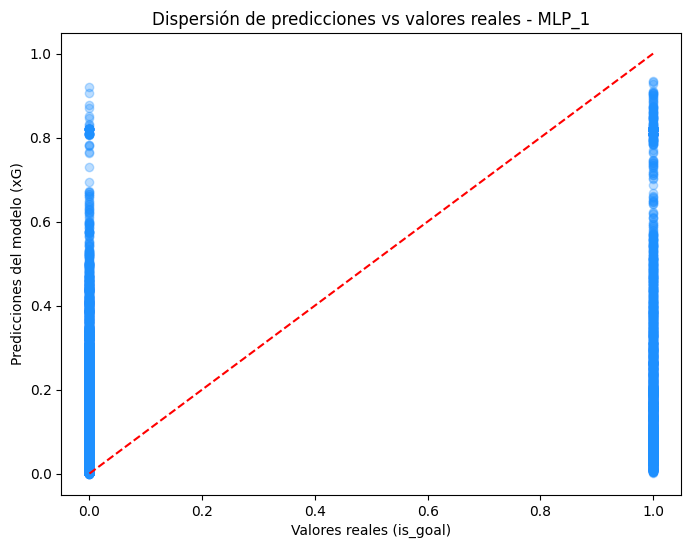

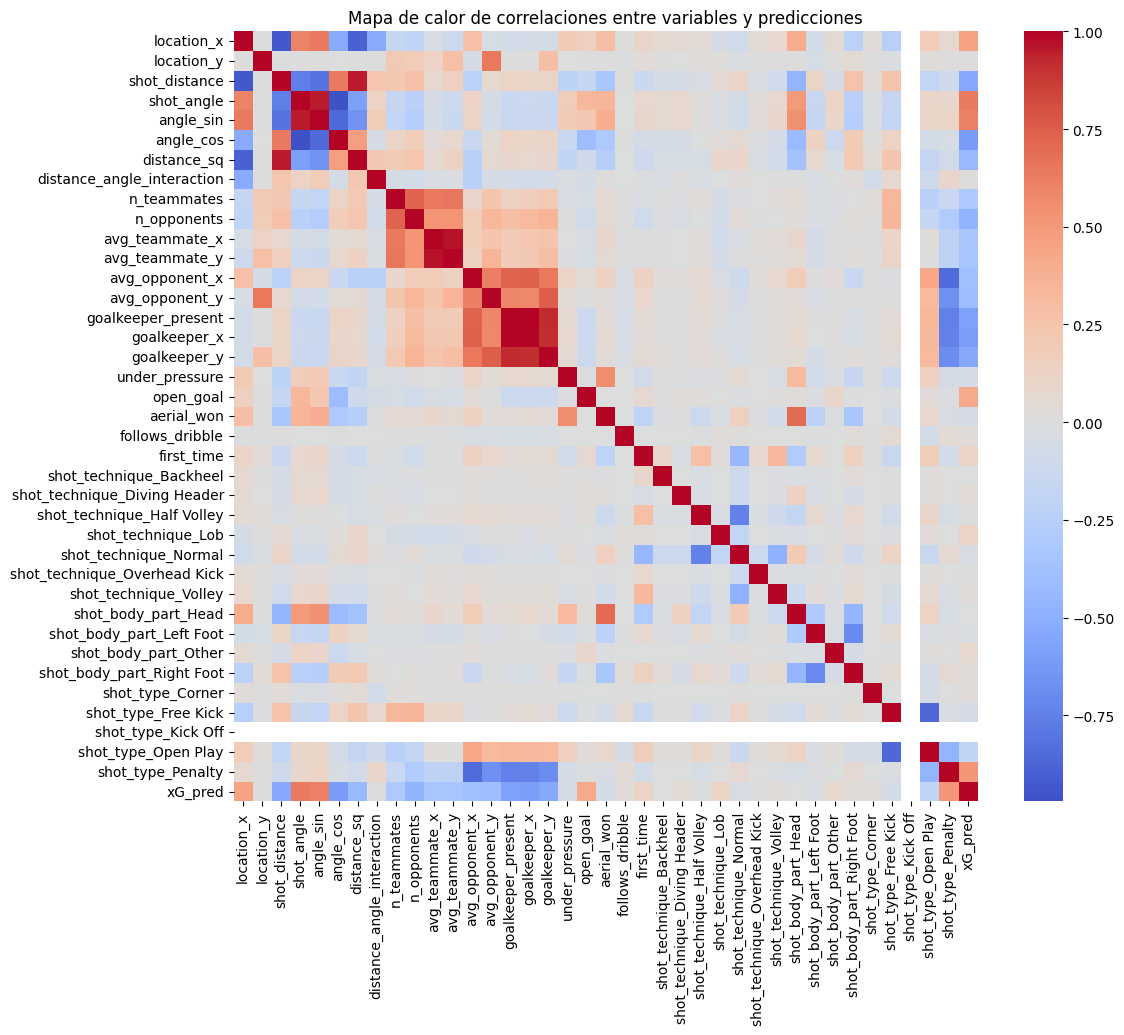

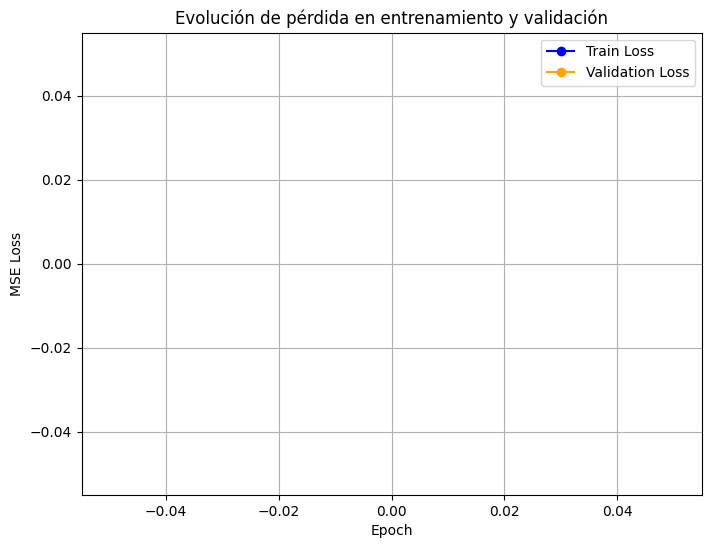

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# 3) Gráfico de dispersión de predicciones vs valores reales
# -------------------------------------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_val, y_val_pred, alpha=0.3, color='dodgerblue')
plt.plot([0,1],[0,1], color='red', linestyle='--')  # línea y=x
plt.xlabel("Valores reales (is_goal)")
plt.ylabel("Predicciones del modelo (xG)")
plt.title("Dispersión de predicciones vs valores reales - MLP_1")
plt.show()

# -------------------------------------------------------------------
# 4) Mapa de calor de correlaciones
# -------------------------------------------------------------------
# Crear DataFrame con predicciones y variables de entrada
df_corr = pd.DataFrame(X_val_scaled, columns=feature_cols)
df_corr["xG_pred"] = y_val_pred

# Calcular correlaciones
corr_matrix = df_corr.corr()

# Visualizar mapa de calor
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, fmt=".2f", cbar=True)
plt.title("Mapa de calor de correlaciones entre variables y predicciones")
plt.show()

# -------------------------------------------------------------------
# 5) Comparativa de pérdida en entrenamiento vs validación
# -------------------------------------------------------------------
# Asumimos que guardaste train_loss_list y val_loss_list durante entrenamiento
# Si no, puedes modificar el bucle de entrenamiento para guardar losses por epoch
train_loss_list = []  # lista de pérdidas de entrenamiento por epoch
val_loss_list = []    # lista de pérdidas de validación por epoch

# Ejemplo para plot (rellena con tus listas reales)
epochs_range = range(1, len(train_loss_list)+1)

plt.figure(figsize=(8,6))
plt.plot(epochs_range, train_loss_list, label="Train Loss", color="blue", marker="o")
plt.plot(epochs_range, val_loss_list, label="Validation Loss", color="orange", marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Evolución de pérdida en entrenamiento y validación")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-537838108.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_features.values, y=top10_features.index, palette="viridis")


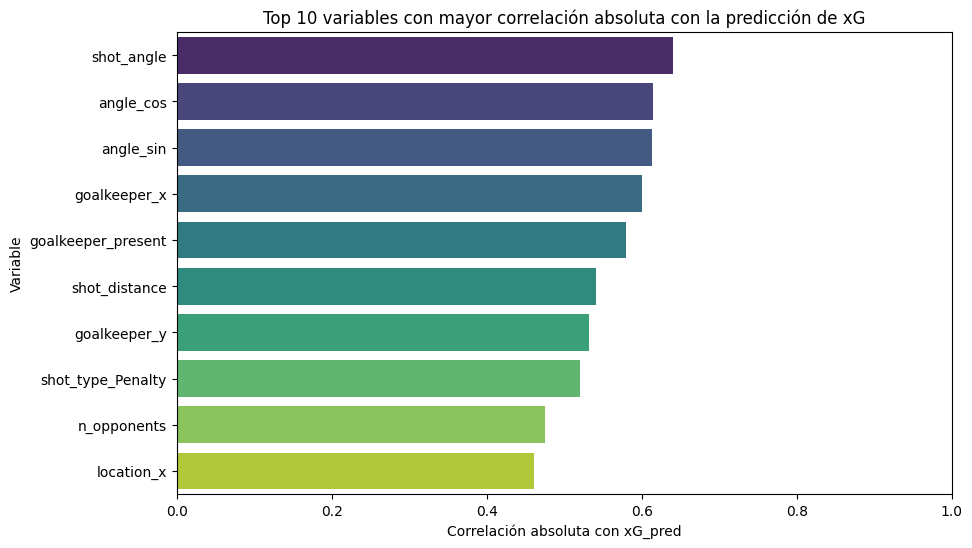

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# df_corr: DataFrame con X_val_scaled y columna 'xG_pred'
# Ya lo tienes definido en tu gráfico de heatmap

# 1) Calcular correlaciones absolutas con la predicción
corr_with_pred = corr_matrix["xG_pred"].drop("xG_pred")  # excluir autocorrelación
corr_with_pred_abs = corr_with_pred.abs()

# 2) Seleccionar las 10 variables más correlacionadas
top10_features = corr_with_pred_abs.sort_values(ascending=False).head(10)

# 3) Graficar barplot
plt.figure(figsize=(10,6))
sns.barplot(x=top10_features.values, y=top10_features.index, palette="viridis")
plt.xlabel("Correlación absoluta con xG_pred")
plt.ylabel("Variable")
plt.title("Top 10 variables con mayor correlación absoluta con la predicción de xG")
plt.xlim(0,1)
plt.show()


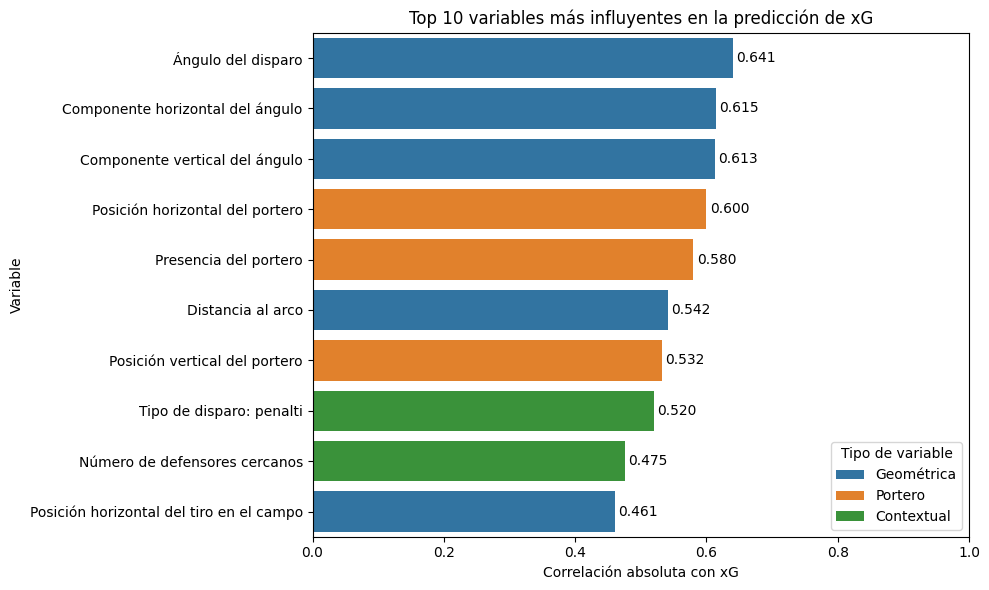

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Valores exactos de correlación absoluta
top10_vars = {
    "Ángulo del disparo": 0.640601,
    "Componente horizontal del ángulo": 0.614806,
    "Componente vertical del ángulo": 0.612842,
    "Posición horizontal del portero": 0.599972,
    "Presencia del portero": 0.580095,
    "Distancia al arco": 0.541529,
    "Posición vertical del portero": 0.532025,
    "Tipo de disparo: penalti": 0.519997,
    "Número de defensores cercanos": 0.475384,
    "Posición horizontal del tiro en el campo": 0.460739
}

# Clasificación de variables por tipo
var_type = {
    "Ángulo del disparo": "Geométrica",
    "Componente horizontal del ángulo": "Geométrica",
    "Componente vertical del ángulo": "Geométrica",
    "Posición horizontal del portero": "Portero",
    "Presencia del portero": "Portero",
    "Distancia al arco": "Geométrica",
    "Posición vertical del portero": "Portero",
    "Tipo de disparo: penalti": "Contextual",
    "Número de defensores cercanos": "Contextual",
    "Posición horizontal del tiro en el campo": "Geométrica"
}

# Convertir a DataFrame
df_top10 = pd.DataFrame({
    "Variable": list(top10_vars.keys()),
    "Correlación": list(top10_vars.values()),
    "Tipo": [var_type[v] for v in top10_vars.keys()]
})

# Colores por tipo de variable
palette = {"Geométrica": "#1f77b4", "Portero": "#ff7f0e", "Contextual": "#2ca02c"}

# Crear barplot
plt.figure(figsize=(10,6))
sns.barplot(
    x="Correlación",
    y="Variable",
    data=df_top10,
    hue="Tipo",
    dodge=False,
    palette=palette
)

# Añadir anotaciones con el valor de correlación
for i, (val, var) in enumerate(zip(df_top10["Correlación"], df_top10["Variable"])):
    plt.text(val + 0.005, i, f"{val:.3f}", va='center')

plt.xlabel("Correlación absoluta con xG")
plt.ylabel("Variable")
plt.title("Top 10 variables más influyentes en la predicción de xG")
plt.xlim(0,1)
plt.legend(title="Tipo de variable", loc="lower right")
plt.tight_layout()
plt.show()

Dimensiones del dataset: (87111, 56)

Tipos de variables:
event_id                         object
match_id                          int64
player                           object
team                             object
minute                            int64
location_x                      float64
location_y                      float64
under_pressure                     bool
open_goal                          bool
aerial_won                         bool
follows_dribble                    bool
first_time                         bool
is_goal                            bool
statsbomb_xg                    float64
freeze_frame                     object
key_pass_id                      object
shot_technique_Backheel            bool
shot_technique_Diving Header       bool
shot_technique_Half Volley         bool
shot_technique_Lob                 bool
shot_technique_Normal              bool
shot_technique_Overhead Kick       bool
shot_technique_Volley              bool
shot_body_part_Head   

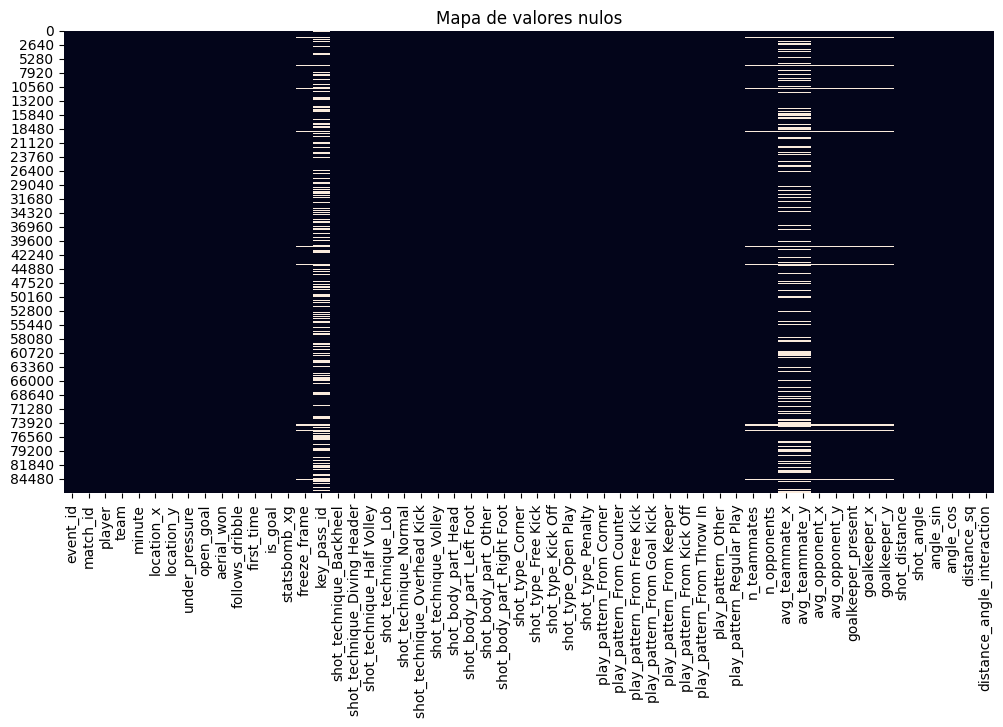


Estadísticas de variables numéricas:
           match_id        minute    location_x    location_y  statsbomb_xg  \
count  8.711100e+04  87111.000000  87111.000000  87111.000000  87111.000000   
mean   2.970974e+06     49.070049    103.571454     39.761377      0.106297   
std    1.558242e+06     27.207676      8.802520      9.894899      0.149382   
min    7.298000e+03      0.000000     30.200000      0.300000      0.000180   
25%    3.749233e+06     26.000000     97.300000     32.500000      0.027673   
50%    3.825632e+06     49.000000    105.000000     40.000000      0.054790   
75%    3.879845e+06     72.000000    110.600000     47.000000      0.110060   
max    3.943077e+06    139.000000    120.500000     80.000000      0.995122   

        n_teammates   n_opponents  avg_teammate_x  avg_teammate_y  \
count  85932.000000  85932.000000    65864.000000    65864.000000   
mean       1.599835      5.075827      104.937725       40.217095   
std        1.361208      2.003947        7.

<Figure size 1000x1500 with 0 Axes>

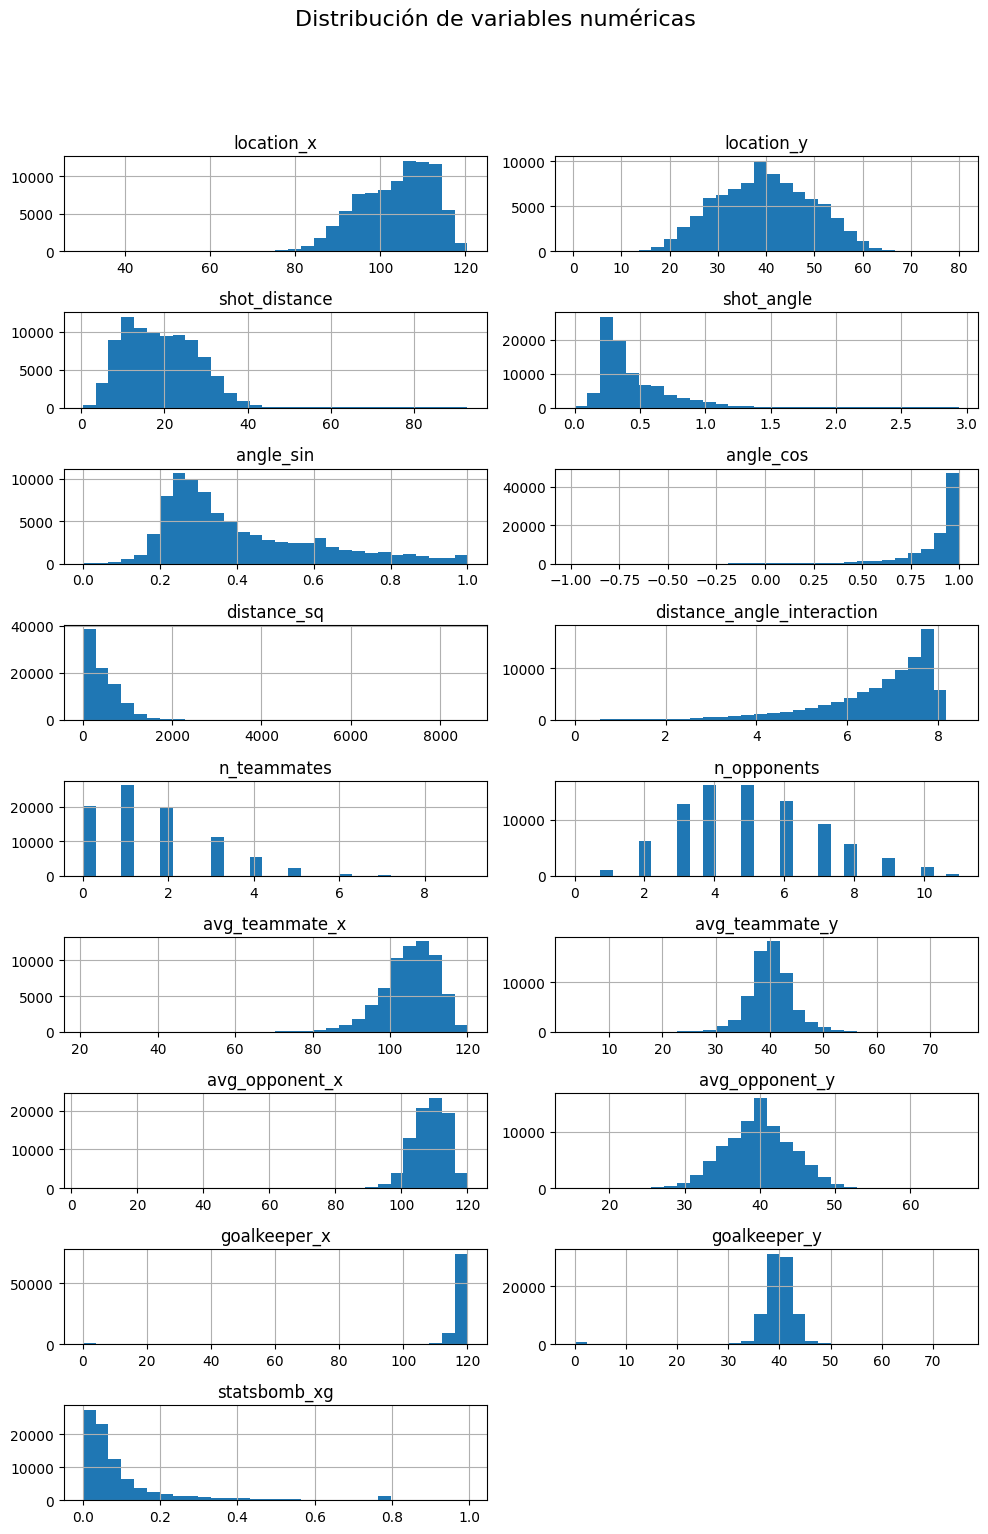


Frecuencia de la variable shot_technique_Backheel:
shot_technique_Backheel
False    86775
True       336
Name: count, dtype: int64

Frecuencia de la variable shot_technique_Diving Header:
shot_technique_Diving Header
False    86781
True       330
Name: count, dtype: int64

Frecuencia de la variable shot_technique_Half Volley:
shot_technique_Half Volley
False    75518
True     11593
Name: count, dtype: int64

Frecuencia de la variable shot_technique_Lob:
shot_technique_Lob
False    86246
True       865
Name: count, dtype: int64

Frecuencia de la variable shot_technique_Normal:
shot_technique_Normal
True     67956
False    19155
Name: count, dtype: int64

Frecuencia de la variable shot_technique_Overhead Kick:
shot_technique_Overhead Kick
False    86660
True       451
Name: count, dtype: int64

Frecuencia de la variable shot_technique_Volley:
shot_technique_Volley
False    81531
True      5580
Name: count, dtype: int64

Frecuencia de la variable shot_body_part_Head:
shot_body_part_Head


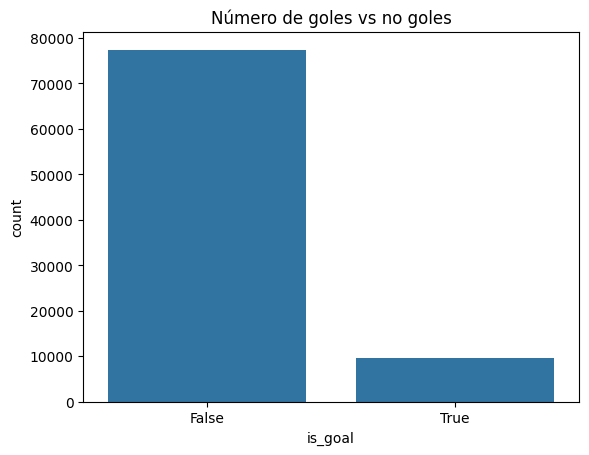

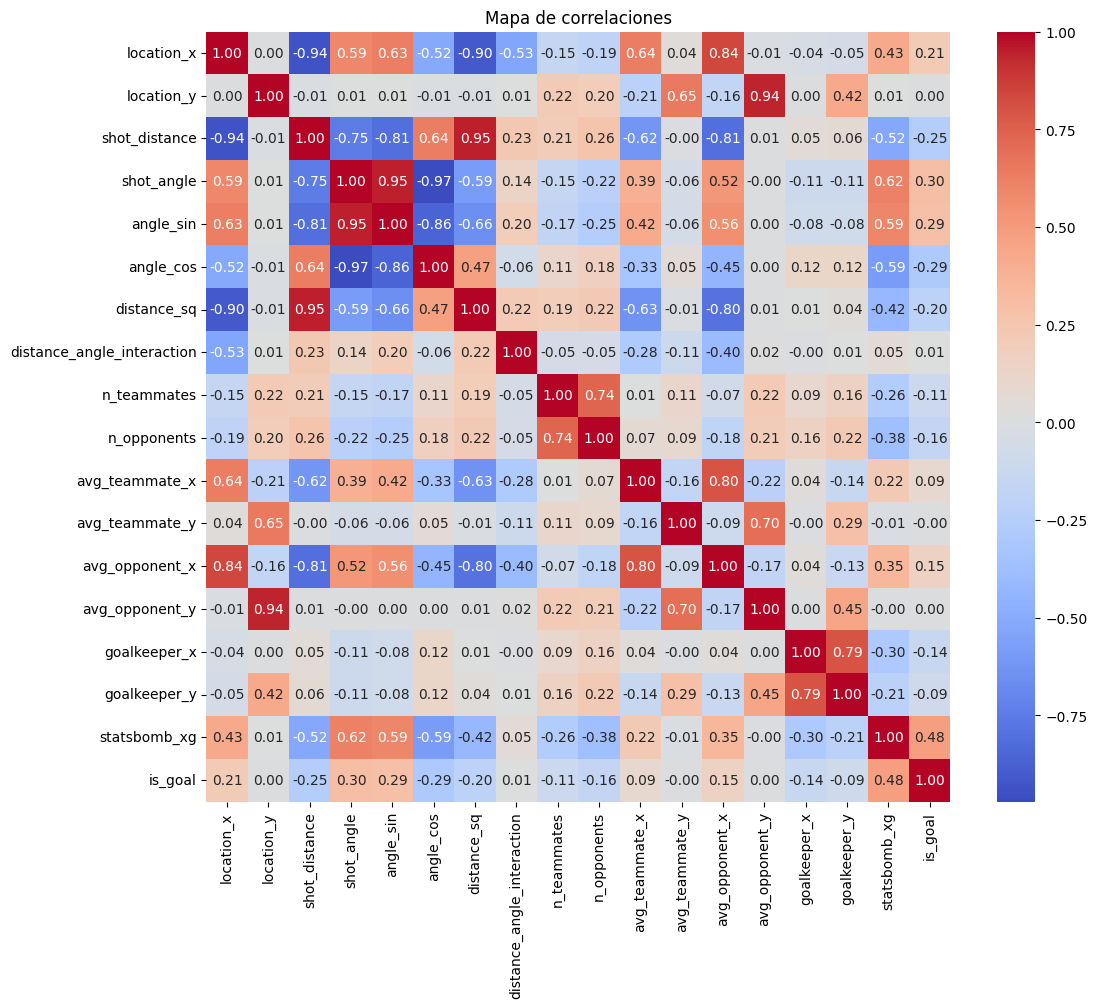

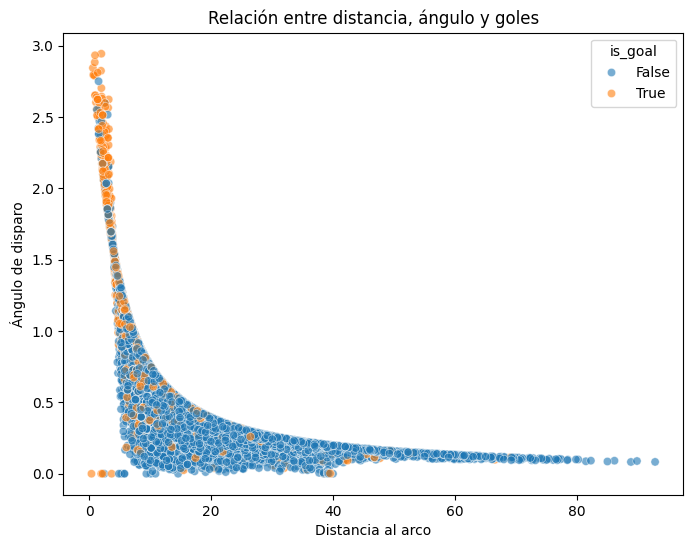

Insights iniciales:
- La mayoría de los disparos se concentran en las zonas cercanas al arco (location_x elevado).
- La probabilidad de gol tiende a aumentar con menor distancia y mayor ángulo favorable.
- La presencia del portero y de defensores cercanos podría influir en la eficacia del disparo.
- Algunas variables categóricas como shot_technique o shot_body_part tienen muchas categorías poco frecuentes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset final
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, log_loss, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pickle
df = pd.read_csv('/content/drive/MyDrive/tfg/datos.csv')
# -------------------------------------------------------------------
# 0) Preparación inicial
# -------------------------------------------------------------------
# df: tu DataFrame principal con features y target 'is_goal'

# -------------------------------------------------------------------
# 1) Rellenar nulos y tipos
# -------------------------------------------------------------------


# -------------------------------------------------------------------
# 2) Ingeniería de variables geométricas
# -------------------------------------------------------------------
GOAL_X = 120.0
POST_LOW_Y = 36.0
POST_HIGH_Y = 44.0
GOAL_CENTER_Y = 40.0

def shot_distance(x, y):
    return np.sqrt((GOAL_X - x)**2 + (GOAL_CENTER_Y - y)**2)

def shot_angle(x, y):
    dx = GOAL_X - x
    if dx <= 0:
        return 0.0
    dy1 = POST_HIGH_Y - y
    dy2 = POST_LOW_Y - y
    v1 = np.array([dx, dy1], dtype=float)
    v2 = np.array([dx, dy2], dtype=float)
    dot = (v1 * v2).sum()
    cross = abs(v1[0]*v2[1] - v1[1]*v2[0])
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return np.arctan2(cross, dot)

for col in ["location_x", "location_y"]:
    if col not in df.columns:
        df[col] = np.nan

df["shot_distance"] = df[["location_x","location_y"]].apply(
    lambda r: shot_distance(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan, axis=1)
df["shot_angle"] = df[["location_x","location_y"]].apply(
    lambda r: shot_angle(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan, axis=1)

df["angle_sin"] = np.sin(df["shot_angle"])
df["angle_cos"] = np.cos(df["shot_angle"])
df["distance_sq"] = df["shot_distance"]**2
df["distance_angle_interaction"] = df["shot_distance"] * df["shot_angle"]
# ----------------------------------------
# 1. Información general del dataset
# ----------------------------------------
print("Dimensiones del dataset:", df.shape)
print("\nTipos de variables:")
print(df.dtypes)
print("\nPrimeras filas del dataset:")
print(df.head())

# ----------------------------------------
# 2. Valores nulos
# ----------------------------------------
print("\nValores nulos por columna:")
print(df.isna().sum())

# Visualización de nulos
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

# ----------------------------------------
# 3. Estadísticas descriptivas
# ----------------------------------------
print("\nEstadísticas de variables numéricas:")
print(df.describe())

# Distribuciones de variables numéricas
num_cols = ['location_x','location_y','shot_distance','shot_angle',
            'angle_sin','angle_cos','distance_sq','distance_angle_interaction',
            'n_teammates','n_opponents','avg_teammate_x','avg_teammate_y',
            'avg_opponent_x','avg_opponent_y','goalkeeper_x','goalkeeper_y','statsbomb_xg']

plt.figure(figsize=(10, 15))
df[num_cols].hist(bins=30, figsize=(10, 15), layout=(9, 2))
plt.suptitle("Distribución de variables numéricas", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])  # deja espacio arriba para el título
plt.show()

# ----------------------------------------
# 4. Variables categóricas
# ----------------------------------------
cat_cols = [c for c in df.columns if c.startswith('shot_technique_')
                               or c.startswith('shot_body_part_') or c.startswith('shot_type_')or c.startswith('play_pattern_')]

for col in cat_cols:
    counts = df[col].value_counts()
    print(f"\nFrecuencia de la variable {col}:")
    print(counts.head(10))

# ----------------------------------------
# 5. Variable objetivo
# ----------------------------------------
print("\nDistribución de goles vs no goles:")
print(df['is_goal'].value_counts())

sns.countplot(x='is_goal', data=df)
plt.title("Número de goles vs no goles")
plt.show()

# ----------------------------------------
# 6. Correlaciones
# ----------------------------------------
plt.figure(figsize=(12,10))
corr = df[num_cols + ['is_goal']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Mapa de correlaciones")
plt.show()

# ----------------------------------------
# 7. Relación distancia/ángulo con goles
# ----------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='shot_distance', y='shot_angle', hue='is_goal', data=df, alpha=0.6)
plt.title("Relación entre distancia, ángulo y goles")
plt.xlabel("Distancia al arco")
plt.ylabel("Ángulo de disparo")
plt.show()

# ----------------------------------------
# 8. Resumen de insights iniciales
# ----------------------------------------
print("Insights iniciales:")
print("- La mayoría de los disparos se concentran en las zonas cercanas al arco (location_x elevado).")
print("- La probabilidad de gol tiende a aumentar con menor distancia y mayor ángulo favorable.")
print("- La presencia del portero y de defensores cercanos podría influir en la eficacia del disparo.")
print("- Algunas variables categóricas como shot_technique o shot_body_part tienen muchas categorías poco frecuentes.")

In [ ]:
df_pred = df.copy()
xg_pred = predict_xg(df_pred)
print(xg_pred[27])  # probabilidades (xG)

0.36381808


In [ ]:

df_pred[df_pred['is_goal'] == True]['statsbomb_xg']

,statsbomb_xg
19,0.083203
25,0.105343
27,0.420624
39,0.092323
47,0.461249
...,...
87066,0.209921
87070,0.242951
87081,0.763771
87085,0.183282


In [ ]:
df_pred[df_pred['is_goal']==True]

,event_id,match_id,player,team,minute,location_x,location_y,under_pressure,open_goal,aerial_won,...,avg_opponent_y,goalkeeper_present,goalkeeper_x,goalkeeper_y,shot_distance,shot_angle,angle_sin,angle_cos,distance_sq,distance_angle_interaction
19,f8132d81-31dc-45ec-ae0a-455471f6aba7,15946,Lionel Andrés Messi Cuccittini,Barcelona,63,97.8,45.4,0,0,0,...,40.760,1,119.2,38.7,22.847319,0.337555,0.331181,0.943567,522.00,7.712224
25,2b88907c-eb80-4782-88fa-1837baa9cbb6,15946,Philippe Coutinho Correia,Barcelona,82,105.3,33.4,0,0,0,...,37.000,1,117.2,38.2,16.113659,0.449679,0.434677,0.900587,259.65,7.245978
27,036c1a04-8d9b-40c0-8b35-780df67fab4d,15946,Lionel Andrés Messi Cuccittini,Barcelona,91,111.5,36.2,0,0,0,...,37.475,1,116.0,37.3,9.310746,0.766005,0.693262,0.720686,86.69,7.132077
39,416e1326-31ef-4cff-a219-112321d2aab8,15956,Ousmane Dembélé,Barcelona,56,111.9,49.0,0,0,0,...,42.080,1,118.2,43.7,12.108262,0.460550,0.444441,0.895808,146.61,5.576456
47,fe70ba6c-fece-406a-abb2-59de31cedc3a,15973,Juan Camilo Hernández Suárez,Huesca,2,115.4,36.6,0,0,0,...,39.950,1,118.2,37.9,5.720140,1.144333,0.910434,0.413654,32.72,6.545743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87066,7f8ffcb0-8e3a-455e-8782-a0c19fa4115c,9928,Lionel Andrés Messi Cuccittini,Barcelona,44,115.2,33.1,0,0,0,...,36.000,1,118.5,36.0,8.405355,0.612504,0.574918,0.818211,70.65,5.148318
87070,de32973b-f7c0-42ac-8245-e9d0d53e05be,9928,Nicola Sansone,Villarreal,53,109.8,40.6,0,0,0,...,38.300,1,118.0,39.8,10.217632,0.745419,0.678280,0.734803,104.40,7.616422
87081,0cd2f622-8de5-40b3-89c3-258e2a09101a,9928,Ousmane Dembélé,Barcelona,86,116.8,36.2,0,1,0,...,40.800,1,118.9,40.8,4.967897,1.243898,0.947043,0.321107,24.68,6.179559
87085,055fe6ef-c3b0-4061-88c9-d2a77c87b27b,9928,Ousmane Dembélé,Barcelona,92,102.4,37.6,0,0,0,...,38.100,1,107.4,37.7,17.762883,0.439431,0.425424,0.904994,315.52,7.805559


In [ ]:
from sklearn.metrics import mean_squared_error

# Asegúrate de que no haya nulos
df_valid = df_pred.dropna(subset=["statsbomb_xg", "is_goal"])

y_true = df_valid["is_goal"].values
y_pred = xg_pred

mse = mean_squared_error(y_true, y_pred)
print(f"Error cuadrático medio entre statsbomb_xg y is_goal: {mse:.6f}")

Error cuadrático medio entre statsbomb_xg y is_goal: 0.075872


In [ ]:
df_pred.head()

,event_id,match_id,player,team,minute,location_x,location_y,under_pressure,open_goal,aerial_won,...,play_pattern_From Keeper,play_pattern_From Kick Off,play_pattern_From Throw In,play_pattern_Other,play_pattern_Regular Play,shot_distance,shot_angle,angle_sin,angle_cos,distance_sq
0,becd7956-ce44-479e-8fc9-16a2d1f1f349,15946,Lionel Andrés Messi Cuccittini,Barcelona,2,111.5,52.9,0,0,0,...,False,False,True,False,False,15.448625,0.296402,0.292081,0.956394,238.66
1,9107d374-2942-4876-a14f-1b9f86901c15,15946,Jordi Alba Ramos,Barcelona,5,113.9,26.4,0,0,0,...,False,False,False,False,True,14.905368,0.232420,0.230333,0.973112,222.17
2,ddd194ca-08fb-43d0-87c2-33647f975f9f,15946,Lionel Andrés Messi Cuccittini,Barcelona,15,93.7,34.7,0,0,0,...,True,False,False,False,False,26.828716,0.290500,0.286431,0.958101,719.78
3,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,15946,Rubén Sobrino Pozuelo,Deportivo Alavés,16,109.2,39.1,1,0,1,...,False,False,False,False,True,10.837435,0.705452,0.648378,0.761319,117.45
4,3ed2b107-be17-42d5-9d1b-25006a0e55cb,15946,Luis Alberto Suárez Díaz,Barcelona,18,107.8,24.7,0,0,0,...,False,False,False,False,False,19.568597,0.259971,0.257053,0.966397,382.93


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Cargar datos
df = pd.read_csv("drive/MyDrive/tfg/shots_data.csv")

# Elegir solo tiros válidos con resultado conocido
df = df[df['shot_outcome'].notna()]

# Convertir objetivo: 1 si fue gol, 0 en otro caso
df['is_goal'] = df['shot_outcome'].apply(lambda x: 1 if x == "Goal" else 0)

# Seleccionar variables para el modelo
features = [
    "location_x", "location_y",
    "under_pressure", "shot_technique", "shot_body_part"
]
df = df[features + ["is_goal"]].dropna()

# Codificar variables categóricas
df = pd.get_dummies(df, columns=["shot_technique", "shot_body_part"], drop_first=True)

# Separar X e y
X = df.drop("is_goal", axis=1)
y = df["is_goal"]

# Normalizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separar conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Construir el modelo
model = Sequential()
model.add(Dense(64, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))  # Salida de probabilidad

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop])

# Evaluar
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Precisión del modelo: {accuracy:.2f}")

KeyboardInterrupt: 

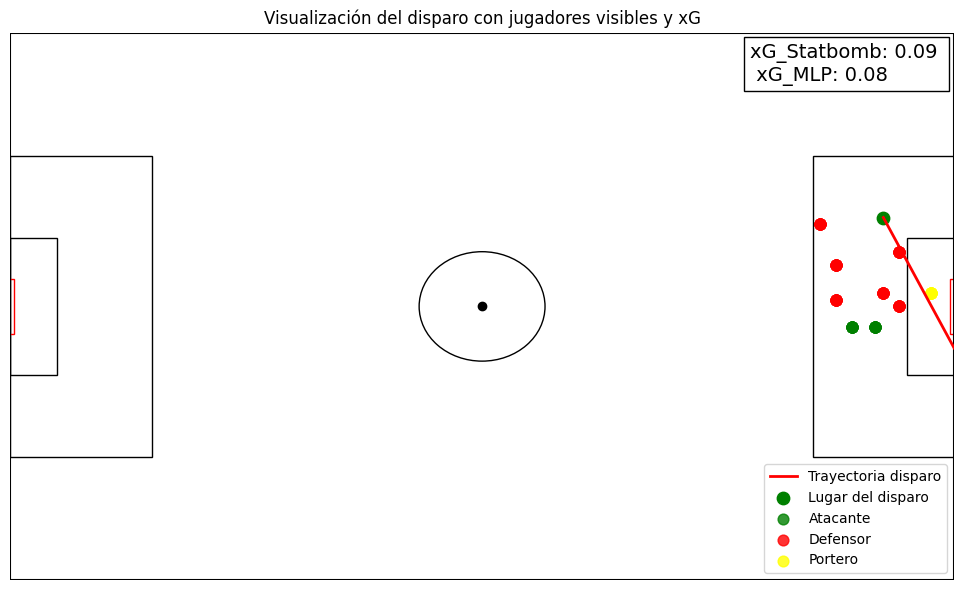

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Cargar datos
shots_df = pd.read_csv("drive/MyDrive/tfg/shots_data2.csv")
players_df = pd.read_csv("drive/MyDrive/tfg/visible_players_data.csv")


# Puedes cambiar a un ID específico
s=2300
# Extraer información del disparo
shot = shots_df.loc[s]
visible_players = players_df[players_df['event_id'] == shot['event_id']]

# Crear el campo de fútbol
def draw_pitch(ax):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)

    # Líneas exteriores
    plt.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color="black")

    # Área grande
    ax.add_patch(patches.Rectangle((0, 18), 18, 44, fill=False))
    ax.add_patch(patches.Rectangle((102, 18), 18, 44, fill=False))

    # Área pequeña
    ax.add_patch(patches.Rectangle((0, 30), 6, 20, fill=False))
    ax.add_patch(patches.Rectangle((114, 30), 6, 20, fill=False))

    # Círculo central
    ax.add_patch(plt.Circle((60, 40), 8, color="black", fill=False))
    ax.plot(60, 40, 'ko')

    # Porterías
    ax.add_patch(patches.Rectangle((-1.5, 36), 2, 8, color="red", fill=False))
    ax.add_patch(patches.Rectangle((121.5, 36), -2, 8, color="red", fill=False))

    ax.axis('off')
    return ax

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))
draw_pitch(ax)

# Color de la trayectoria según el resultado
color_linea = 'green' if shot['shot_outcome'] == 'Goal' else 'red'

# Dibujar disparo
ax.plot([shot['location_x'], shot['shot_end_x']],
        [shot['location_y'], shot['shot_end_y']],
        color=color_linea, linewidth=2, label='Trayectoria disparo')
ax.scatter(shot['location_x'], shot['location_y'], color='green', s=80, label='Lugar del disparo')

# Dibujar jugadores visibles
for _, player in visible_players.iterrows():
    for _, player in visible_players.iterrows():
      p=eval(player['position_in_frame'])
      if p['id']==1 and not player['teammate']:
          color = 'yellow'
          label = 'Portero'
      elif player['teammate']:
          color = 'green'
          label = 'Atacante'
      else:
          color = 'red'
          label = 'Defensor'

      ax.scatter(
          player['player_position_x'], player['player_position_y'],
          color=color, s=60, alpha=0.8, label=label
      )

# Mostrar valor xG
ax.text(94, 73, f"xG_Statbomb: {shot['statsbomb_xg']:.2f} \n xG_MLP: {xg_pred[s]:.2f}", fontsize=14, color='black', bbox=dict(facecolor='white'))

# Leyenda sin duplicados
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc='lower right')

plt.title("Visualización del disparo con jugadores visibles y xG")
plt.tight_layout()
plt.show()


In [ ]:
xg_pred[1]

np.float32(0.049961455)

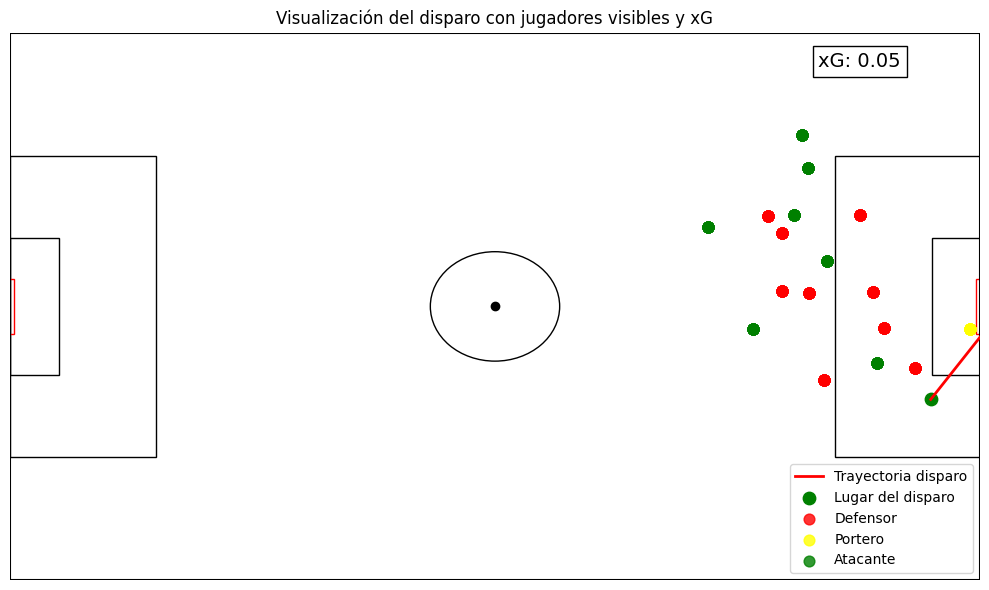

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Cargar datos
shots_df = pd.read_csv("drive/MyDrive/tfg/shots_data2.csv")
players_df = pd.read_csv("drive/MyDrive/tfg/visible_players_data.csv")


# Puedes cambiar a un ID específico

# Extraer información del disparo
shot = shots_df.loc[1]
visible_players = players_df[players_df['event_id'] == shot['event_id']]

# Crear el campo de fútbol
def draw_pitch(ax):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)

    # Líneas exteriores
    plt.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color="black")

    # Área grande
    ax.add_patch(patches.Rectangle((0, 18), 18, 44, fill=False))
    ax.add_patch(patches.Rectangle((102, 18), 18, 44, fill=False))

    # Área pequeña
    ax.add_patch(patches.Rectangle((0, 30), 6, 20, fill=False))
    ax.add_patch(patches.Rectangle((114, 30), 6, 20, fill=False))

    # Círculo central
    ax.add_patch(plt.Circle((60, 40), 8, color="black", fill=False))
    ax.plot(60, 40, 'ko')

    # Porterías
    ax.add_patch(patches.Rectangle((-1.5, 36), 2, 8, color="red", fill=False))
    ax.add_patch(patches.Rectangle((121.5, 36), -2, 8, color="red", fill=False))

    ax.axis('off')
    return ax

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))
draw_pitch(ax)

# Color de la trayectoria según el resultado
color_linea = 'green' if shot['shot_outcome'] == 1 else 'red'

# Dibujar disparo
ax.plot([shot['location_x'], shot['shot_end_x']],
        [shot['location_y'], shot['shot_end_y']],
        color=color_linea, linewidth=2, label='Trayectoria disparo')
ax.scatter(shot['location_x'], shot['location_y'], color='green', s=80, label='Lugar del disparo')

# Dibujar jugadores visibles
for _, player in visible_players.iterrows():
    for _, player in visible_players.iterrows():
      p=eval(player['position_in_frame'])
      if p['id']==1 and not player['teammate']:
          color = 'yellow'
          label = 'Portero'
      elif player['teammate']:
          color = 'green'
          label = 'Atacante'
      else:
          color = 'red'
          label = 'Defensor'

      ax.scatter(
          player['player_position_x'], player['player_position_y'],
          color=color, s=60, alpha=0.8, label=label
      )

# Mostrar valor xG
ax.text(100, 75, f"xG: {shot['statsbomb_xg']:.2f}", fontsize=14, color='black', bbox=dict(facecolor='white'))

# Leyenda sin duplicados
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc='lower right')

plt.title("Visualización del disparo con jugadores visibles y xG")
plt.tight_layout()
plt.show()


KeyError: 'shot_end_x'

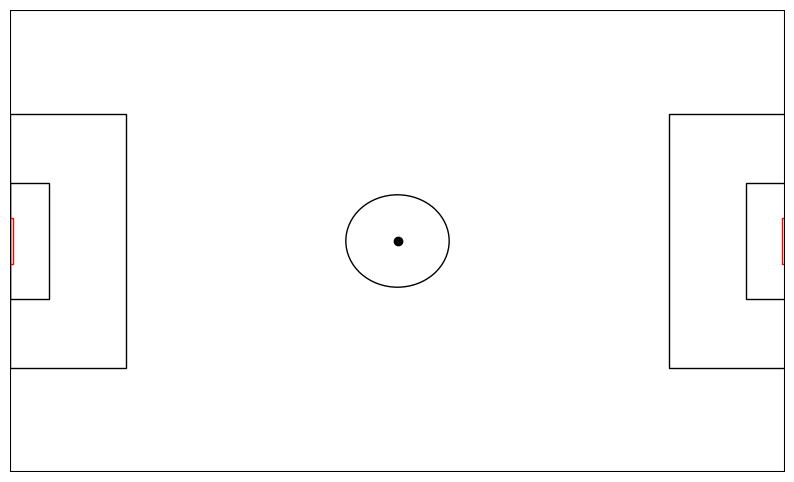

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Función para dibujar el campo
def draw_pitch(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color="black")
    ax.add_patch(patches.Rectangle((0, 18), 18, 44, fill=False))
    ax.add_patch(patches.Rectangle((102, 18), 18, 44, fill=False))
    ax.add_patch(patches.Rectangle((0, 30), 6, 20, fill=False))
    ax.add_patch(patches.Rectangle((114, 30), 6, 20, fill=False))
    ax.add_patch(plt.Circle((60, 40), 8, color="black", fill=False))
    ax.plot(60, 40, 'ko')
    ax.add_patch(patches.Rectangle((-1.5, 36), 2, 8, color="red", fill=False))
    ax.add_patch(patches.Rectangle((121.5, 36), -2, 8, color="red", fill=False))
    ax.axis('off')
    return ax

# Carpeta para guardar gráficos
output_dir = "shots_situations"
os.makedirs(output_dir, exist_ok=True)

# Definir las situaciones a graficar
situations = {
    "Bajo presion": df['under_pressure'] == 1,
    "Sin presion": df['under_pressure'] == 0,
    "Porteria abierta": df['open_goal'] == 1,
    "Portero presente": df['goalkeeper_present'] == 1,
    "Penalti": df['shot_type_Penalty'] == 1,
    "Tiro normal": df['shot_type_Penalty'] == 0,
    "Tras regate": df['follows_dribble'] == 1,
    "De primera": df['first_time'] == 1
}

# Generar gráficos por situación
for situation_name, condition in situations.items():
    shots_situation = df[condition]
    for idx, shot in shots_situation.iterrows():
        fig, ax = plt.subplots(figsize=(10, 6))
        draw_pitch(ax)

        color_linea = 'green' if shot['is_goal'] == 1 else 'red'
        ax.plot([shot['location_x'], shot['shot_end_x']],
                [shot['location_y'], shot['shot_end_y']],
                color=color_linea, linewidth=2)
        ax.scatter(shot['location_x'], shot['location_y'], color=color_linea, s=80)
        ax.text(100, 75, f"xG: {shot['predicted_xg']:.2f}", fontsize=14,
                color='black', bbox=dict(facecolor='white'))

        ax.scatter([], [], color='green', s=80, label='Gol')
        ax.scatter([], [], color='red', s=80, label='No Gol')
        ax.legend(loc='lower right')

        plt.title(f"{situation_name} - Disparo ID {shot['event_id']}")
        plt.tight_layout()
        filename = os.path.join(output_dir, f"{situation_name}_shot_{shot['event_id']}.png")
        plt.savefig(filename)
        plt.close(fig)

print(f"✅ Gráficos generados por situación en '{output_dir}'")

In [ ]:
shots_df = pd.read_csv("drive/MyDrive/tfg/shots_data.csv")
players_df = pd.read_csv("drive/MyDrive/tfg/visible_players_data.csv")

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, log_loss, roc_auc_score

# Asegurarse de que no hay nulos en las columnas
df_eval = df.dropna(subset=['is_goal', 'statsbomb_xg'])

# Valores reales y predichos
y_true = df_eval['is_goal'].values
y_pred = df_eval['statsbomb_xg'].values

# 1) Error Cuadrático Medio (MSE)
mse_statbomb = mean_squared_error(y_true, y_pred)

# 2) Log Loss
logloss_statbomb = log_loss(y_true, y_pred)  # eps evita log(0)

# 3) Área bajo la curva ROC (AUC)
auc_statbomb = roc_auc_score(y_true, y_pred)

print(f"MSE StatBomb xG: {mse_statbomb:.6f}")
print(f"Log Loss StatBomb xG: {logloss_statbomb:.6f}")
print(f"AUC StatBomb xG: {auc_statbomb:.6f}")

MSE StatBomb xG: 0.076040
Log Loss StatBomb xG: 0.266797
AUC StatBomb xG: 0.824192


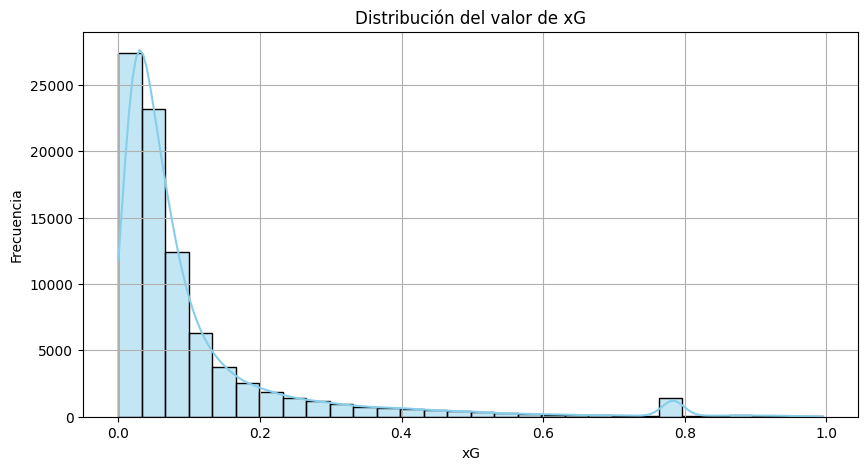

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
shots_df = pd.read_csv("drive/MyDrive/tfg/shots_data.csv")
plt.figure(figsize=(10, 5))
sns.histplot(shots_df['statsbomb_xg'], bins=30, kde=True, color='skyblue')
plt.title("Distribución del valor de xG")
plt.xlabel("xG")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

/tmp/ipython-input-34-1034764292.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=shots_df, x='shot_outcome', order=shots_df['shot_outcome'].value_counts().index, palette='Set2')


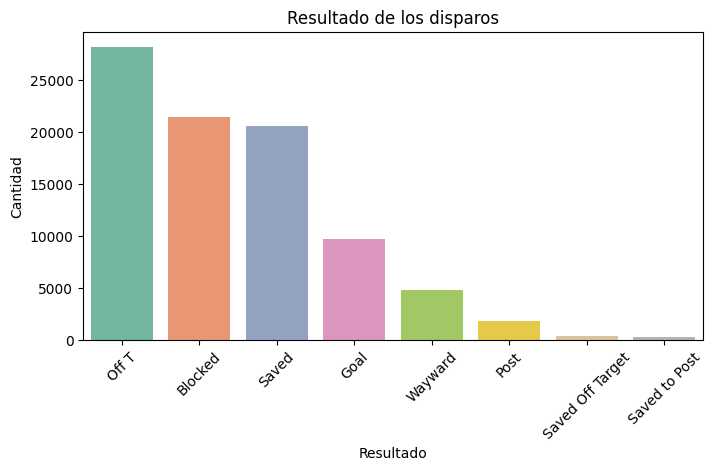

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=shots_df, x='shot_outcome', order=shots_df['shot_outcome'].value_counts().index)
plt.title("Resultado de los disparos")
plt.xlabel("Resultado")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-35-1107100897.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=shots_df, x='shot_technique', order=shots_df['shot_technique'].value_counts().index, palette='coolwarm')


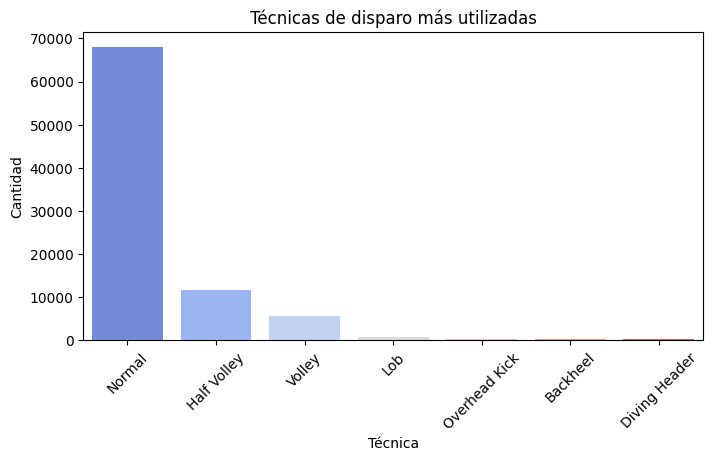

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=shots_df, x='shot_technique', order=shots_df['shot_technique'].value_counts().index, palette='coolwarm')
plt.title("Técnicas de disparo más utilizadas")
plt.xlabel("Técnica")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-36-272954036.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=shots_df, x='shot_body_part', order=shots_df['shot_body_part'].value_counts().index, palette='viridis')


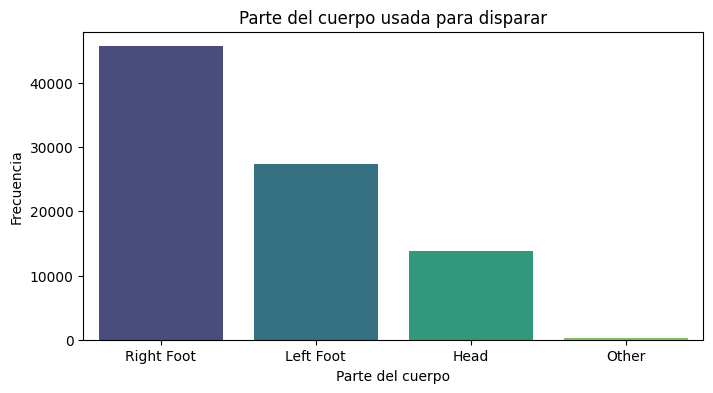

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=shots_df, x='shot_body_part', order=shots_df['shot_body_part'].value_counts().index, palette='viridis')
plt.title("Parte del cuerpo usada para disparar")
plt.xlabel("Parte del cuerpo")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(
    x=shots_df['location_x'],
    y=shots_df['location_y'],
    cmap="Reds", shade=True, bw_adjust=0.5)
plt.title("Mapa de calor de los lugares desde donde se disparó")
plt.xlabel("Posición X")
plt.ylabel("Posición Y")
plt.xlim(60, 120)
plt.ylim(0, 80)
plt.gca().invert_yaxis()  # Invertir para alinearse con el campo de fútbol
plt.show()

/tmp/ipython-input-1566413200.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


/tmp/ipython-input-2402540654.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipython-input-2402540654.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipython-input-2402540654.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


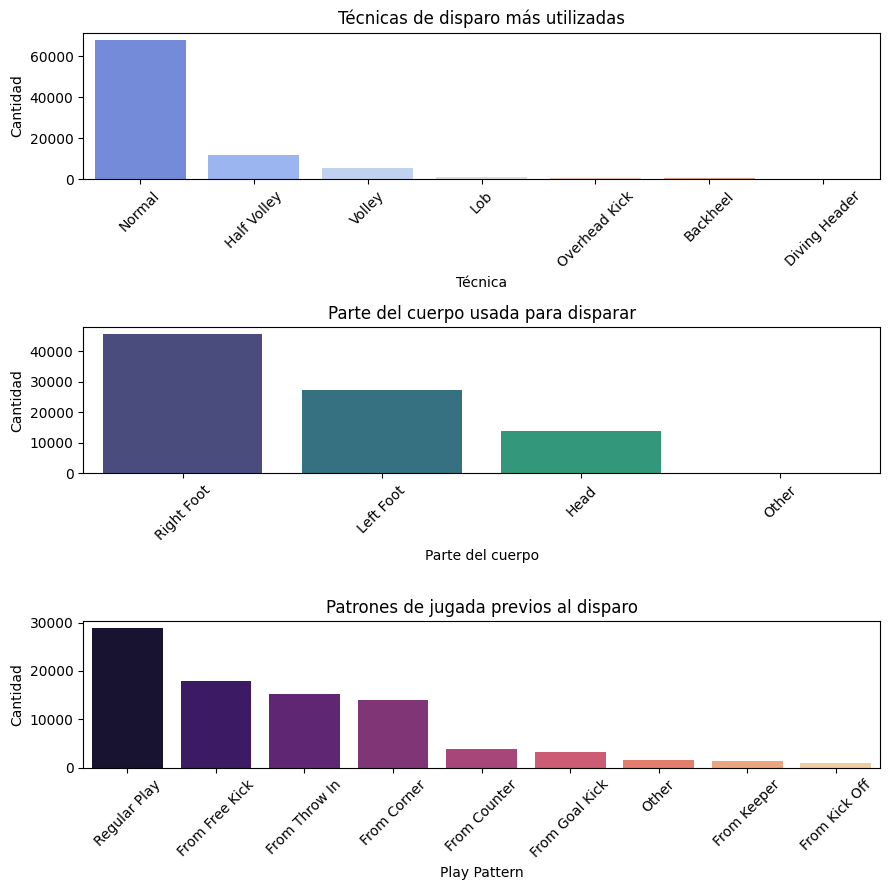

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(9, 9))  # 1 fila, 3 columnas

# Gráfico 1: Técnicas de disparo
sns.countplot(
    data=shots_df,
    x='shot_technique',
    order=shots_df['shot_technique'].value_counts().index,
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title("Técnicas de disparo más utilizadas")
axes[0].set_xlabel("Técnica")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Parte del cuerpo
sns.countplot(
    data=shots_df,
    x='shot_body_part',
    order=shots_df['shot_body_part'].value_counts().index,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("Parte del cuerpo usada para disparar")
axes[1].set_xlabel("Parte del cuerpo")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis='x', rotation=45)

# Gráfico 3: Play patterns
sns.countplot(
    data=shots_df,
    x='play_pattern',
    order=shots_df['play_pattern'].value_counts().index,
    palette='magma',
    ax=axes[2]
)
axes[2].set_title("Patrones de jugada previos al disparo")
axes[2].set_xlabel("Play Pattern")
axes[2].set_ylabel("Cantidad")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

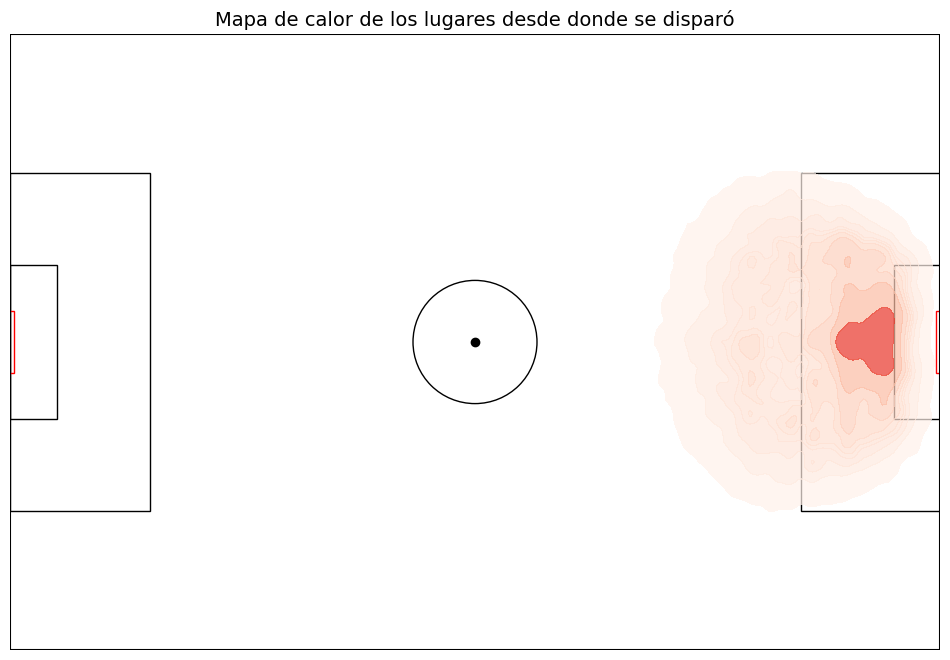

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

def draw_pitch(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)

    # Líneas exteriores
    ax.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color="black")

    # Áreas grandes
    ax.add_patch(patches.Rectangle((0, 18), 18, 44, fill=False))
    ax.add_patch(patches.Rectangle((102, 18), 18, 44, fill=False))

    # Áreas pequeñas
    ax.add_patch(patches.Rectangle((0, 30), 6, 20, fill=False))
    ax.add_patch(patches.Rectangle((114, 30), 6, 20, fill=False))

    # Círculo central
    ax.add_patch(plt.Circle((60, 40), 8, color="black", fill=False))
    ax.plot(60, 40, 'ko')

    # Porterías
    ax.add_patch(patches.Rectangle((-1.5, 36), 2, 8, color="red", fill=False))
    ax.add_patch(patches.Rectangle((121.5, 36), -2, 8, color="red", fill=False))

    ax.axis('off')
    return ax


# Crear figura y eje
fig, ax = plt.subplots(figsize=(12, 8))
ax = draw_pitch(ax)

# Mapa de calor KDE sobre el campo
sns.kdeplot(
    x=shots_df['location_x'],
    y=shots_df['location_y'],
    cmap="Reds", fill=True, bw_adjust=0.5, alpha=0.7, ax=ax
)

ax.set_title("Mapa de calor de los lugares desde donde se disparó", fontsize=14)
plt.gca().invert_yaxis()  # Alinear con orientación del campo
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, log_loss, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pickle


# -------------------------------------------------------------------
# 1) Agregar features agregadas por tiro
# -------------------------------------------------------------------


# -------------------------------------------------------------------
# 2) Preparar DataFrame principal y unir freeze frame
# -------------------------------------------------------------------

# Rellenar nulos
fill_median_cols = ["n_teammates","n_opponents","avg_teammate_x","avg_teammate_y",
                    "avg_opponent_x","avg_opponent_y","goalkeeper_x","goalkeeper_y"]
for c in fill_median_cols:
    df[c] = df[c].fillna(0)
bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time","goalkeeper_present"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)
# -------------------------------------------------------------------
# 3) Ingeniería de variables geométricas
# -------------------------------------------------------------------
GOAL_X = 120.0
POST_LOW_Y = 36.0
POST_HIGH_Y = 44.0
GOAL_CENTER_Y = 40.0

def shot_distance(x, y):
    return np.sqrt((GOAL_X - x)**2 + (GOAL_CENTER_Y - y)**2)

def shot_angle(x, y):
    dx = GOAL_X - x
    if dx <= 0:
        return 0.0
    dy1 = POST_HIGH_Y - y
    dy2 = POST_LOW_Y - y
    v1 = np.array([dx, dy1], dtype=float)
    v2 = np.array([dx, dy2], dtype=float)
    dot = (v1 * v2).sum()
    cross = abs(v1[0]*v2[1] - v1[1]*v2[0])
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return np.arctan2(cross, dot)

for col in ["location_x", "location_y", "under_pressure", "open_goal",
            "aerial_won", "follows_dribble", "first_time"]:
    if col not in df.columns:
        df[col] = np.nan

df["shot_distance"] = df[["location_x","location_y"]].apply(
    lambda r: shot_distance(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)
df["shot_angle"] = df[["location_x","location_y"]].apply(
    lambda r: shot_angle(r["location_x"], r["location_y"]) if pd.notnull(r["location_x"]) else np.nan,
    axis=1
)

df["angle_sin"] = np.sin(df["shot_angle"])
df["angle_cos"] = np.cos(df["shot_angle"])
df["distance_sq"] = df["shot_distance"]**2
df["distance_angle_interaction"] = df["shot_distance"] * df["shot_angle"]

bool_cols = ["under_pressure", "open_goal", "aerial_won", "follows_dribble", "first_time"]
for c in bool_cols:
    df[c] = df[c].fillna(0).astype(int)

geom_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin",
             "angle_cos","distance_sq","distance_angle_interaction"]
for c in geom_cols:
    df[c] = df[c].fillna(df[c].median())

# -------------------------------------------------------------------
# 4) Selección de features
# -------------------------------------------------------------------
prefixes = ["shot_technique_", "shot_body_part_", "shot_type_"]
dummy_cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]

num_cols = ["location_x","location_y","shot_distance","shot_angle","angle_sin","angle_cos",
            "distance_sq","distance_angle_interaction","n_teammates","n_opponents",
            "avg_teammate_x","avg_teammate_y","avg_opponent_x","avg_opponent_y",
            "goalkeeper_present","goalkeeper_x","goalkeeper_y"] + bool_cols

feature_cols = num_cols + dummy_cols

df = df.dropna(subset=["is_goal"])
y = df["is_goal"].astype(float).values
X = df[feature_cols].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Tensores PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32)

# ---------------------------------------------------------
# 2) Función para entrenar MLP
# ---------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_layers=[256,128,64], dropout=0.3, activation='relu'):
        super().__init__()
        layers = []
        act_func = nn.ReLU if activation=='relu' else nn.LeakyReLU
        last_dim = in_dim
        for h in hidden_layers:
            layers.append(nn.Linear(last_dim,h))
            layers.append(act_func())
            layers.append(nn.Dropout(dropout))
            last_dim = h
        layers.append(nn.Linear(last_dim,1))
        self.net = nn.Sequential(*layers)
    def forward(self,x):
        return self.net(x)

def train_mlp(hidden_layers=[256,128,64], dropout=0.3, lr=1e-3, weight_decay=1e-4, epochs=50, batch_size=512, loss_fn='mse'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLP(X_train_t.shape[1], hidden_layers=hidden_layers, dropout=dropout).to(device)

    criterion = nn.MSELoss() if loss_fn=='mse' else nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds = TensorDataset(X_val_t, y_val_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    best_val_mse = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        for xb,yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = torch.sigmoid(model(xb)) if loss_fn=='bce' else model(xb)
            loss = criterion(out,yb)
            loss.backward()
            optimizer.step()

        # Validación
        model.eval()
        all_preds = []
        with torch.no_grad():
          for xb,_ in val_loader:
              xb = xb.to(device)
              preds = torch.sigmoid(model(xb)) if loss_fn=='bce' else model(xb)
              all_preds.append(preds.detach().cpu().numpy())
        y_pred = np.vstack(all_preds).ravel()
        val_mse = mean_squared_error(y_val, y_pred)
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = model.state_dict()

    # Cargar mejor modelo
    model.load_state_dict(best_state)
    y_pred = np.vstack([torch.sigmoid(model(X_val_t.to(device))).detach().cpu().numpy()]).ravel()
    metrics = {
        'MSE': mean_squared_error(y_val,y_pred),
        'LogLoss': log_loss(y_val,y_pred),
        'AUC': roc_auc_score(y_val,y_pred)
    }
    return model, metrics

# ---------------------------------------------------------
# 3) Función para entrenar modelos clásicos
# ---------------------------------------------------------
def train_classic(model):
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_val_scaled)[:,1]
    metrics = {
        'MSE': mean_squared_error(y_val, y_pred_proba),
        'LogLoss': log_loss(y_val, y_pred_proba),
        'AUC': roc_auc_score(y_val, y_pred_proba)
    }
    return metrics

# ---------------------------------------------------------
# 4) Experimentos
# ---------------------------------------------------------
experiment_results = {}

# a) MLP variantes
mlp_configs = [
    {'hidden_layers':[128,64], 'dropout':0.2},
    {'hidden_layers':[256,128,64], 'dropout':0.3},  # original
    {'hidden_layers':[512,256,128], 'dropout':0.4}
]

for i, cfg in enumerate(mlp_configs):
    _, metrics = train_mlp(hidden_layers=cfg['hidden_layers'], dropout=cfg['dropout'])
    experiment_results[f'MLP_{i}'] = metrics

# b) MLP con BCE
_, metrics = train_mlp(hidden_layers=[256,128,64], dropout=0.3, loss_fn='bce')
experiment_results['MLP_BCE'] = metrics

# c) Modelos clásicos
classic_models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True)
}

for name, model in classic_models.items():
    metrics = train_classic(model)
    experiment_results[name] = metrics

# d) Mostrar resultados
results_df = pd.DataFrame(experiment_results).T
print(results_df)
